# Basic 2D U-Net baseline — Kaggle TPU, seven-fold subject-wise CV

This is a standalone baseline notebook derived from the supplied pipeline. It intentionally contains **no nnU-Net or PyTorch training**. It performs the confirmed preprocessing, verifies the saved arrays, converts them to TPU-friendly TFRecords, and runs all seven leave-one-subject-out (LOSO) folds automatically.

Experimental guarantees:

- subjects: `SUBB8`, `SUBB16`, `SUBB26`, `SUBB36`, `SUBB40`, `SUBB45`, `SUBB54`;
- mask correction: vertical flip;
- crop: `x=70:128`, `y=32:226`, producing `194×58`;
- each fold trains on six complete subjects and tests once on the seventh;
- subject-balanced and positive/empty-mask-balanced sampling;
- fixed 60-epoch budget; the held-out subject is never used for model selection;
- predictions are unpadded to `194×58` before evaluation.

### Before running

In Kaggle choose **Settings → Accelerator → TPU VM**, attach the same seven raw datasets, then select **Run all**. Do not select a GPU runtime for this notebook.

Typical total runtime is approximately **1.5–3 hours**. The first fold can be slower because TPU/XLA compiles the model. Dataset location, TPU generation, host I/O, and Kaggle load can move the runtime outside this range. The notebook records actual per-fold times and prints an updated ETA after every fold.


## 0. Initialize the TPU and fixed experiment configuration


In [1]:
# ============================================================
# Kaggle TPU v5e-8 bootstrap + experiment configuration
# THIS MUST BE THE FIRST CODE CELL
# ============================================================

import os
import sys
import shutil
import subprocess
import importlib.metadata
import warnings

# These must be set before importing TensorFlow or JAX
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["JAX_PLATFORMS"] = "cpu"

# There is no NVIDIA GPU in the TPU runtime.
# This prevents the irrelevant CUDA initialization error.
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

warnings.filterwarnings(
    "ignore",
    message="Transparent hugepages are not enabled.*",
)

TPU_TENSORFLOW_VERSION = "2.18.0"


# ------------------------------------------------------------
# Make sure TensorFlow has not already been imported
# ------------------------------------------------------------

if "tensorflow" in sys.modules:
    raise RuntimeError(
        "TensorFlow was already imported in this session. "
        "Restart or Factory Reset the Kaggle session, then run "
        "this cell first."
    )


# ------------------------------------------------------------
# Install TPU-enabled TensorFlow
# ------------------------------------------------------------

print("Preparing TensorFlow for Kaggle TPU v5e-8...")


if shutil.which("uv"):

    # Kaggle's preferred fast package installer
    subprocess.run(
        [
            "uv",
            "pip",
            "uninstall",
            "--system",
            "jax",
            "jaxlib",
        ],
        check=False,
    )

    install_command = [
        "uv",
        "pip",
        "install",
        "--system",
        "tensorflow-tpu==2.18.0",
        "--find-links",
        "https://storage.googleapis.com/"
        "libtpu-tf-releases/index.html",
    ]

else:

    # Fallback if uv is unavailable
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "uninstall",
            "-y",
            "jax",
            "jaxlib",
        ],
        check=False,
    )

    install_command = [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--upgrade",
        "tensorflow-tpu==2.18.0",
        "--find-links",
        "https://storage.googleapis.com/"
        "libtpu-tf-releases/index.html",
    ]


try:
    subprocess.check_call(install_command)

except subprocess.CalledProcessError as exc:
    raise RuntimeError(
        "tensorflow-tpu could not be installed. "
        "Make sure Kaggle Internet is ON, then Factory Reset "
        "the session and run this cell again."
    ) from exc


try:
    installed_tpu_version = importlib.metadata.version(
        "tensorflow-tpu"
    )

except importlib.metadata.PackageNotFoundError as exc:
    raise RuntimeError(
        "tensorflow-tpu was not installed successfully."
    ) from exc


print(
    "Installed tensorflow-tpu:",
    installed_tpu_version,
)

if installed_tpu_version != TPU_TENSORFLOW_VERSION:
    raise RuntimeError(
        "Expected tensorflow-tpu "
        f"{TPU_TENSORFLOW_VERSION}, found "
        f"{installed_tpu_version}"
    )


# ------------------------------------------------------------
# Import scientific packages only after TPU TensorFlow install
# ------------------------------------------------------------

from pathlib import Path
import gc
import hashlib
import json
import random
import re
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.patches import Rectangle
from numpy.lib.format import open_memmap

import tensorflow as tf


if tf.__version__ != TPU_TENSORFLOW_VERSION:
    raise RuntimeError(
        f"Expected TensorFlow {TPU_TENSORFLOW_VERSION}, "
        f"but imported {tf.__version__}. "
        "Factory Reset the session and run this cell first."
    )


# ------------------------------------------------------------
# Experiment configuration
# ------------------------------------------------------------

SEED = 42

SUBJECTS = [
    "SUBB8",
    "SUBB16",
    "SUBB26",
    "SUBB36",
    "SUBB40",
    "SUBB45",
    "SUBB54",
]

FOLDS_TO_RUN = list(
    range(len(SUBJECTS))
)

DATA_ROOT = Path(
    "/kaggle/input"
)

PREPROCESSING_ROOT = Path(
    "/kaggle/working/subb_preprocessed_194x58"
)

WORK_ROOT = Path(
    "/kaggle/working/subb_unet_tpu"
)

TFRECORD_ROOT = (
    WORK_ROOT / "tfrecords"
)

RESULT_ROOT = (
    WORK_ROOT / "results"
)

for directory in [
    PREPROCESSING_ROOT,
    WORK_ROOT,
    TFRECORD_ROOT,
    RESULT_ROOT,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )


ORIGINAL_SHAPE = (
    194,
    58,
)

MODEL_SHAPE = (
    208,
    64,
)

EPOCHS = 60

GLOBAL_BATCH_SIZE = 128

STEPS_PER_EPOCH = 32

INITIAL_LR = 1e-3

POSITIVE_FRACTION = 0.70

BASE_FILTERS = 32

STEPS_PER_EXECUTION = (
    STEPS_PER_EPOCH
)

TFRECORD_SHARDS_PER_CLASS = 4


random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)


# ------------------------------------------------------------
# Initialize Kaggle TPU v5e-8
# ------------------------------------------------------------

print(
    "\nInitializing Kaggle TPU v5e-8..."
)

try:

    resolver = (
        tf.distribute.cluster_resolver
        .TPUClusterResolver(
            tpu="local"
        )
    )

    tf.config.experimental_connect_to_cluster(
        resolver
    )

    tf.tpu.experimental.initialize_tpu_system(
        resolver
    )

    STRATEGY = tf.distribute.TPUStrategy(
        resolver
    )

except Exception as exc:

    raise RuntimeError(
        "TPU initialization failed even after installing "
        "tensorflow-tpu. Verify that TPU v5e-8 and Internet "
        "were enabled before starting the session."
    ) from exc


REPLICAS = (
    STRATEGY.num_replicas_in_sync
)

logical_tpus = (
    tf.config.list_logical_devices("TPU")
)

if REPLICAS < 2:
    raise RuntimeError(
        "TensorFlow did not create a distributed TPU strategy. "
        f"Replicas detected: {REPLICAS}"
    )

if GLOBAL_BATCH_SIZE % REPLICAS != 0:
    raise ValueError(
        f"GLOBAL_BATCH_SIZE={GLOBAL_BATCH_SIZE} "
        f"is not divisible by {REPLICAS} replicas."
    )


# TPU-efficient numerical policy
tf.keras.mixed_precision.set_global_policy(
    "mixed_bfloat16"
)


# ------------------------------------------------------------
# Final audit
# ------------------------------------------------------------

print("\nTPU initialization successful")
print("TensorFlow:", tf.__version__)
print("Logical TPU devices:", len(logical_tpus))
print("TPU replicas:", REPLICAS)
print("Global batch:", GLOBAL_BATCH_SIZE)

print(
    "Per-replica batch:",
    GLOBAL_BATCH_SIZE // REPLICAS,
)

print(
    "Folds scheduled:",
    FOLDS_TO_RUN,
)

print(
    "Samples per epoch:",
    GLOBAL_BATCH_SIZE * STEPS_PER_EPOCH,
)

Preparing TensorFlow for Kaggle TPU v5e-8...
Found existing installation: jax 0.10.2
Uninstalling jax-0.10.2:
  Successfully uninstalled jax-0.10.2
Found existing installation: jaxlib 0.10.2
Uninstalling jaxlib-0.10.2:
  Successfully uninstalled jaxlib-0.10.2


Looking in links: https://storage.googleapis.com/libtpu-tf-releases/index.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.9/123.9 MB 41.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 234.4/234.4 MB 34.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 8.7 MB/s eta 0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 19.1 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 48.8 MB/s eta 0:00:00
  Attempting uninstall: libtpu
    Found existing installation: libtpu 0.0.17
    Uninstalling libtpu-0.0.17:
      Successfully uninstalled libtpu-0.0.17
  Attempting uninstall: protobuf
    Found existing installation: protobuf 7.35.1
    Uninstalling protobuf-7.35.1:
      Successfully uninstalled protobuf-7.35.1
  Attempting uninstall: numpy
    Found existing installation: numpy 2.5.0
    Uninstalling numpy-2.5.0:
      Successfully uninstalled numpy-2.5.0
  Attempting uninstall: 

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
orbax-checkpoint 0.12.1 requires jax>=0.6.0, which is not installed.
flax 0.12.7 requires jax>=0.10.0, which is not installed.
trax 1.4.1 requires jax, which is not installed.
trax 1.4.1 requires jaxlib, which is not installed.
google-metrax 0.2.4 requires jax>=0.6.2, which is not installed.
jraph 0.0.6.dev0 requires jax>=0.1.55, which is not installed.
jraph 0.0.6.dev0 requires jaxlib>=0.1.37, which is not installed.
chex 0.1.92 requires jax>=0.7.0, which is not installed.
chex 0.1.92 requires jaxlib>=0.7.0, which is not installed.
clu 0.0.12 requires jax, which is not installed.
clu 0.0.12 requires jaxlib, which is not installed.
optax 0.2.8 requires jax>=0.5.3, which is not installed.
optax 0.2.8 requires jaxlib>=0.5.3, which is not installed.
qwix 0.1.8 requires jax, which is not installed.
qwix 0.1.8 requires

Installed tensorflow-tpu: 2.18.0


E0000 00:00:1788380768.958319     592 common_lib.cc:612] Could not set metric server port: INVALID_ARGUMENT: Could not find SliceBuilder port 8471 in any of the 0 ports provided in `tpu_process_addresses`="local"
=== Source Location Trace: ===
learning/45eac/tfrc/runtime/common_lib.cc:230



Initializing Kaggle TPU v5e-8...
INFO:tensorflow:Deallocate tpu buffers before initializing tpu system.
INFO:tensorflow:Initializing the TPU system: local


I0000 00:00:1788380778.791965     592 service.cc:148] XLA service 0x5a19e0f390e0 initialized for platform TPU (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1788380778.791994     592 service.cc:156]   StreamExecutor device (0): TPU, 2a886c8
I0000 00:00:1788380778.791998     592 service.cc:156]   StreamExecutor device (1): TPU, 2a886c8
I0000 00:00:1788380778.792001     592 service.cc:156]   StreamExecutor device (2): TPU, 2a886c8
I0000 00:00:1788380778.792003     592 service.cc:156]   StreamExecutor device (3): TPU, 2a886c8
I0000 00:00:1788380778.792005     592 service.cc:156]   StreamExecutor device (4): TPU, 2a886c8
I0000 00:00:1788380778.792007     592 service.cc:156]   StreamExecutor device (5): TPU, 2a886c8
I0000 00:00:1788380778.792009     592 service.cc:156]   StreamExecutor device (6): TPU, 2a886c8
I0000 00:00:1788380778.792011     592 service.cc:156]   StreamExecutor device (7): TPU, 2a886c8


INFO:tensorflow:Finished initializing TPU system.
INFO:tensorflow:Found TPU system:
INFO:tensorflow:*** Num TPU Cores: 8
INFO:tensorflow:*** Num TPU Workers: 1
INFO:tensorflow:*** Num TPU Cores Per Worker: 8
INFO:tensorflow:*** Available Device: _DeviceAttributes(/job:localhost/replica:0/task:0/device:CPU:0, CPU, 0, 0)
INFO:tensorflow:*** Available Device: _DeviceAttributes(/job:localhost/replica:0/task:0/device:TPU:0, TPU, 0, 0)
INFO:tensorflow:*** Available Device: _DeviceAttributes(/job:localhost/replica:0/task:0/device:TPU:1, TPU, 0, 0)
INFO:tensorflow:*** Available Device: _DeviceAttributes(/job:localhost/replica:0/task:0/device:TPU:2, TPU, 0, 0)
INFO:tensorflow:*** Available Device: _DeviceAttributes(/job:localhost/replica:0/task:0/device:TPU:3, TPU, 0, 0)
INFO:tensorflow:*** Available Device: _DeviceAttributes(/job:localhost/replica:0/task:0/device:TPU:4, TPU, 0, 0)
INFO:tensorflow:*** Available Device: _DeviceAttributes(/job:localhost/replica:0/task:0/device:TPU:5, TPU, 0, 0)
I

## 1. Discover, preprocess, and verify the seven subjects

The following cells are the confirmed preprocessing path from the supplied notebook. The data are memory-mapped, masks are flipped vertically, and the same crop is applied to images and masks. The QA figures remain in this standalone notebook as an integrity record.


## 1. Discover and pair recording/label files

The discovery code tolerates folder names such as `SUBB26_DATA__` and filenames such as `URS26_H3_recordings.npy`. If more than one plausible pair is found for a subject, it stops and asks you to set an exact directory override instead of silently choosing the wrong files.

In [3]:
# ============================================================
# Preprocessing configuration + automatic file discovery
# Run this after the TPU initialization cell
# ============================================================

from pathlib import Path
import re

# Preprocessing output
OUTPUT_ROOT = PREPROCESSING_ROOT

# Confirmed common preprocessing configuration
COMMON = {
    "crop": {
        "x1": 70,
        "x2": 128,
        "y1": 32,
        "y2": 226,
    },
    "flip_mask_vertical": True,
    "mask_threshold": "auto",
    "image_scale": "auto",
}

SUBJECT_CONFIG = {
    subject: {
        **COMMON,
        "crop": dict(COMMON["crop"]),
    }
    for subject in SUBJECTS
}

# None means automatic file discovery.
# If discovery becomes ambiguous, replace None with the exact folder.
SUBJECT_DIR_OVERRIDES = {
    "SUBB8": None,
    "SUBB16": None,
    "SUBB26": None,
    "SUBB36": None,
    "SUBB40": None,
    "SUBB45": None,
    "SUBB54": None,
}

CHUNK_SIZE = 128
QA_FRAMES_PER_SUBJECT = 4
RANDOM_SEED = SEED

EXPECTED_H = (
    COMMON["crop"]["y2"]
    - COMMON["crop"]["y1"]
)

EXPECTED_W = (
    COMMON["crop"]["x2"]
    - COMMON["crop"]["x1"]
)

assert (
    EXPECTED_H,
    EXPECTED_W,
) == (194, 58)

print("Data search root:", DATA_ROOT)
print("Preprocessing output:", OUTPUT_ROOT)
print("Subjects:", SUBJECTS)
print("Expected output shape:", (EXPECTED_H, EXPECTED_W))


# ============================================================
# Automatic recordings/labels discovery
# ============================================================

def subject_number(subject):
    match = re.search(
        r"\d+",
        subject,
    )

    if match is None:
        raise ValueError(
            f"No subject number found in {subject}"
        )

    return int(match.group())


def _npy_role(path):
    name = path.name.lower()

    if (
        "recording" in name
        or "image" in name
    ):
        return "recordings"

    if (
        "label" in name
        or "mask" in name
    ):
        return "labels"

    return None


def _mentions_subject(path, number):
    text = " ".join(
        part.lower()
        for part in path.parts[-4:]
    )

    # Matches 8 or 08 without confusing it
    # with subject numbers such as 18 or 80.
    return (
        re.search(
            rf"(?<!\d)0*{number}(?!\d)",
            text,
        )
        is not None
    )


def find_pair(subject):

    number = subject_number(subject)

    override = SUBJECT_DIR_OVERRIDES.get(
        subject
    )

    search_root = (
        Path(override)
        if override is not None
        else DATA_ROOT
    )

    if not search_root.exists():
        raise FileNotFoundError(
            f"Search root does not exist: "
            f"{search_root}"
        )

    candidates = []

    for path in search_root.rglob("*.npy"):

        role = _npy_role(path)

        subject_matches = (
            override is not None
            or _mentions_subject(
                path,
                number,
            )
        )

        if role is not None and subject_matches:
            candidates.append(
                (path, role)
            )

    recordings = sorted(
        path
        for path, role in candidates
        if role == "recordings"
    )

    labels = sorted(
        path
        for path, role in candidates
        if role == "labels"
    )

    pairs = []

    for recording_path in recordings:

        for label_path in labels:

            if (
                recording_path.parent
                != label_path.parent
            ):
                continue

            recording_prefix = re.split(
                r"recordings?|images?",
                recording_path.stem.lower(),
            )[0].rstrip("_-")

            label_prefix = re.split(
                r"labels?|masks?",
                label_path.stem.lower(),
            )[0].rstrip("_-")

            if recording_prefix == label_prefix:
                pairs.append(
                    (
                        recording_path,
                        label_path,
                    )
                )

    # Remove possible duplicate path pairs
    pairs = list(
        dict.fromkeys(pairs)
    )

    if len(pairs) != 1:

        recording_details = "\n".join(
            f"  {path}"
            for path in recordings
        )

        label_details = "\n".join(
            f"  {path}"
            for path in labels
        )

        raise RuntimeError(
            f"{subject}: expected exactly one "
            f"recording/label pair, but found "
            f"{len(pairs)}.\n\n"
            f"Recording candidates:\n"
            f"{recording_details or '  None'}\n\n"
            f"Label candidates:\n"
            f"{label_details or '  None'}\n\n"
            f"If the correct files are listed, set:\n"
            f"SUBJECT_DIR_OVERRIDES['{subject}'] = "
            f"Path('/kaggle/input/exact-folder-name')"
        )

    return pairs[0]


FILE_PAIRS = {
    subject: find_pair(subject)
    for subject in SUBJECTS
}


print("\nDiscovered input files:")

for subject, paths in FILE_PAIRS.items():

    recording_path, label_path = paths

    print(
        f"\n{subject}"
        f"\n  recording: {recording_path}"
        f"\n  labels:    {label_path}"
    )


if len(FILE_PAIRS) != len(SUBJECTS):
    raise RuntimeError(
        "Not all seven subjects were discovered."
    )

print(
    "\nAll seven recording/label pairs "
    "were discovered successfully."
)

Data search root: /kaggle/input
Preprocessing output: /kaggle/working/subb_preprocessed_194x58
Subjects: ['SUBB8', 'SUBB16', 'SUBB26', 'SUBB36', 'SUBB40', 'SUBB45', 'SUBB54']
Expected output shape: (194, 58)

Discovered input files:

SUBB8
  recording: /kaggle/input/datasets/amitismirabedini/subb8-data/URS08_H1_recordings.npy
  labels:    /kaggle/input/datasets/amitismirabedini/subb8-data/URS08_H1_labels.npy

SUBB16
  recording: /kaggle/input/datasets/amitismirabedini/subb16-data/URS16_H3_recordings.npy
  labels:    /kaggle/input/datasets/amitismirabedini/subb16-data/URS16_H3_labels.npy

SUBB26
  recording: /kaggle/input/datasets/amitismirabedini/subb26-data/URS26_H3_recordings.npy
  labels:    /kaggle/input/datasets/amitismirabedini/subb26-data/URS26_H3_labels.npy

SUBB36
  recording: /kaggle/input/datasets/amitismirabedini/subb36-data/URS36_H2_recordings.npy
  labels:    /kaggle/input/datasets/amitismirabedini/subb36-data/URS36_H2_labels.npy

SUBB40
  recording: /kaggle/input/dataset

## 2. Open arrays and inspect shapes, types, ranges, and frame counts

Only sampled frames are used for range inference. The full frame count and spatial shape still come directly from each array header.

In [4]:
def sample_indices(n, count=32):
    if n <= count:
        return np.arange(n, dtype=int)
    return np.unique(np.linspace(0, n - 1, count, dtype=int))


def sampled_range(array, count=32):
    idx = sample_indices(len(array), count)
    mins, maxs, finite = [], [], []
    for i in idx:
        frame = np.asarray(array[int(i)])
        mins.append(float(np.nanmin(frame)))
        maxs.append(float(np.nanmax(frame)))
        finite.append(bool(np.isfinite(frame).all()))
    return min(mins), max(maxs), all(finite)


DATA = {}
inventory_rows = []

for subject, (rec_path, lab_path) in FILE_PAIRS.items():
    recordings = np.load(rec_path, mmap_mode="r", allow_pickle=False)
    labels = np.load(lab_path, mmap_mode="r", allow_pickle=False)

    if recordings.ndim not in (3, 4) or labels.ndim not in (3, 4):
        raise ValueError(f"{subject}: expected 3D or singleton-channel 4D arrays")
    if recordings.ndim == 4 and recordings.shape[-1] != 1:
        raise ValueError(f"{subject}: recording channel dimension must be 1")
    if labels.ndim == 4 and labels.shape[-1] != 1:
        raise ValueError(f"{subject}: label channel dimension must be 1")
    if len(recordings) != len(labels):
        raise ValueError(f"{subject}: frame mismatch: {len(recordings)} vs {len(labels)}")
    if recordings.shape[1:3] != labels.shape[1:3]:
        raise ValueError(f"{subject}: spatial mismatch: {recordings.shape} vs {labels.shape}")

    rmin, rmax, rfinite = sampled_range(recordings)
    lmin, lmax, lfinite = sampled_range(labels)
    DATA[subject] = {"recordings": recordings, "labels": labels}
    inventory_rows.append({
        "subject": subject,
        "frames": len(recordings),
        "recording_shape": str(recordings.shape),
        "label_shape": str(labels.shape),
        "recording_dtype": str(recordings.dtype),
        "label_dtype": str(labels.dtype),
        "sample_image_min": rmin,
        "sample_image_max": rmax,
        "sample_label_min": lmin,
        "sample_label_max": lmax,
        "sample_all_finite": rfinite and lfinite,
    })

inventory = pd.DataFrame(inventory_rows).set_index("subject")
display(inventory)
print("\nTotal frames:", int(inventory["frames"].sum()))

,frames,recording_shape,label_shape,recording_dtype,label_dtype,sample_image_min,sample_image_max,sample_label_min,sample_label_max,sample_all_finite
subject,,,,,,,,,,
SUBB8,3968,"(3968, 256, 256)","(3968, 256, 256)",float32,float32,0.062745,0.862745,0.0,1.0,True
SUBB16,5392,"(5392, 256, 256)","(5392, 256, 256)",float32,float32,0.062745,0.862745,0.0,1.0,True
SUBB26,4972,"(4972, 256, 256)","(4972, 256, 256)",float32,float32,0.062745,0.862745,0.0,1.0,True
SUBB36,4876,"(4876, 256, 256)","(4876, 256, 256)",float32,float32,0.062745,0.862745,0.0,1.0,True
SUBB40,2618,"(2618, 256, 256)","(2618, 256, 256)",float32,float32,0.062745,0.862745,0.0,1.0,True
SUBB45,6784,"(6784, 256, 256)","(6784, 256, 256)",float32,float32,0.062745,0.862745,0.0,1.0,True
SUBB54,4898,"(4898, 256, 256)","(4898, 256, 256)",float32,float32,0.062745,0.862745,0.0,1.0,True



Total frames: 33508


## 3. Preprocessing functions

The same crop is applied to an image and its corresponding corrected mask. The vertical flip is applied only along the mask's height axis—not along the temporal/frame axis.

In [5]:
def squeeze_frame(frame):
    frame = np.asarray(frame)
    if frame.ndim == 3 and frame.shape[-1] == 1:
        frame = frame[..., 0]
    if frame.ndim != 2:
        raise ValueError(f"Expected a 2D frame, got {frame.shape}")
    return frame


def infer_image_scale(subject):
    configured = SUBJECT_CONFIG[subject]["image_scale"]
    if configured != "auto":
        return float(configured)
    observed_max = float(inventory.loc[subject, "sample_image_max"])
    if observed_max <= 1.5:
        return 1.0
    if observed_max <= 255.0 + 1e-6:
        return 255.0
    raise ValueError(f"{subject}: image max {observed_max} needs an explicit image_scale")


def infer_mask_threshold(subject):
    configured = SUBJECT_CONFIG[subject]["mask_threshold"]
    if configured != "auto":
        return float(configured)
    observed_max = float(inventory.loc[subject, "sample_label_max"])
    return 0.5 if observed_max <= 1.5 else 127.5


def preprocess_frame(subject, frame_index, return_details=False):
    arrays = DATA[subject]
    cfg = SUBJECT_CONFIG[subject]
    image = squeeze_frame(arrays["recordings"][frame_index]).astype(np.float32, copy=True)
    raw_soft_mask = squeeze_frame(arrays["labels"][frame_index]).astype(np.float32, copy=True)

    image /= infer_image_scale(subject)
    image = np.clip(image, 0.0, 1.0)

    corrected_soft_mask = raw_soft_mask
    if cfg["flip_mask_vertical"]:
        corrected_soft_mask = np.flip(corrected_soft_mask, axis=0).copy()

    c = cfg["crop"]
    h, w = image.shape
    if not (0 <= c["x1"] < c["x2"] <= w and 0 <= c["y1"] < c["y2"] <= h):
        raise ValueError(f"{subject}: crop {c} is outside frame shape {(h, w)}")

    image_crop = image[c["y1"]:c["y2"], c["x1"]:c["x2"]]
    soft_crop = corrected_soft_mask[c["y1"]:c["y2"], c["x1"]:c["x2"]]
    mask_crop = (soft_crop >= infer_mask_threshold(subject)).astype(np.uint8)

    expected = (c["y2"] - c["y1"], c["x2"] - c["x1"])
    assert image_crop.shape == mask_crop.shape == expected
    assert np.isfinite(image_crop).all() and np.isfinite(mask_crop).all()

    if return_details:
        return image_crop, mask_crop, image, raw_soft_mask, corrected_soft_mask
    return image_crop, mask_crop


for subject in SUBJECTS:
    image, mask = preprocess_frame(subject, 0)
    print(subject, image.shape, mask.shape, image.dtype, mask.dtype,
          "scale=", infer_image_scale(subject), "threshold=", infer_mask_threshold(subject))

SUBB8 (194, 58) (194, 58) float32 uint8 scale= 1.0 threshold= 0.5
SUBB16 (194, 58) (194, 58) float32 uint8 scale= 1.0 threshold= 0.5
SUBB26 (194, 58) (194, 58) float32 uint8 scale= 1.0 threshold= 0.5
SUBB36 (194, 58) (194, 58) float32 uint8 scale= 1.0 threshold= 0.5
SUBB40 (194, 58) (194, 58) float32 uint8 scale= 1.0 threshold= 0.5
SUBB45 (194, 58) (194, 58) float32 uint8 scale= 1.0 threshold= 0.5
SUBB54 (194, 58) (194, 58) float32 uint8 scale= 1.0 threshold= 0.5


## 4. Full-dataset diagnostics

For each subject this pass counts total, non-empty, and empty masks; measures how much annotated foreground survives the crop; and flags masks touching crop edges. A low retention rate or frequent edge contact suggests that the common crop is unsafe for that subject.

In [6]:
def scan_subject(subject, chunk_size=CHUNK_SIZE):
    labels = DATA[subject]["labels"]
    cfg = SUBJECT_CONFIG[subject]
    c = cfg["crop"]
    threshold = infer_mask_threshold(subject)

    total_fg = retained_fg = 0
    nonempty = edge_touch = 0
    pixel_counts = np.zeros(len(labels), dtype=np.int64)

    for start in range(0, len(labels), chunk_size):
        end = min(start + chunk_size, len(labels))
        block = np.asarray(labels[start:end])
        if block.ndim == 4:
            block = block[..., 0]
        if cfg["flip_mask_vertical"]:
            block = block[:, ::-1, :]
        binary = block >= threshold
        crop = binary[:, c["y1"]:c["y2"], c["x1"]:c["x2"]]

        counts = crop.sum(axis=(1, 2)).astype(np.int64)
        pixel_counts[start:end] = counts
        total_fg += int(binary.sum())
        retained_fg += int(crop.sum())
        nonempty += int((counts > 0).sum())
        touches = crop[:, 0, :].any(1) | crop[:, -1, :].any(1) | crop[:, :, 0].any(1) | crop[:, :, -1].any(1)
        edge_touch += int((touches & (counts > 0)).sum())

    result = {
        "subject": subject,
        "frames": len(labels),
        "nonempty_masks": nonempty,
        "empty_masks": len(labels) - nonempty,
        "nonempty_percent": 100 * nonempty / max(len(labels), 1),
        "foreground_retained_percent": 100 * retained_fg / max(total_fg, 1),
        "nonempty_touching_crop_edge": edge_touch,
        "edge_touch_percent_of_nonempty": 100 * edge_touch / max(nonempty, 1),
    }
    return result, pixel_counts


diagnostic_rows = []
MASK_PIXEL_COUNTS = {}
for subject in SUBJECTS:
    result, counts = scan_subject(subject)
    diagnostic_rows.append(result)
    MASK_PIXEL_COUNTS[subject] = counts

diagnostics = pd.DataFrame(diagnostic_rows).set_index("subject")
display(diagnostics.round(3))

if (diagnostics["foreground_retained_percent"] < 99.0).any():
    warnings.warn("At least one subject retains less than 99% of foreground. Review/expand its crop.")
if (diagnostics["edge_touch_percent_of_nonempty"] > 5.0).any():
    warnings.warn("At least one subject frequently touches a crop edge. Inspect its QA plots carefully.")

,frames,nonempty_masks,empty_masks,nonempty_percent,foreground_retained_percent,nonempty_touching_crop_edge,edge_touch_percent_of_nonempty
subject,,,,,,,
SUBB8,3968,582,3386,14.667,100.000,0,0.000
SUBB16,5392,604,4788,11.202,99.977,0,0.000
SUBB26,4972,600,4372,12.068,100.000,0,0.000
SUBB36,4876,706,4170,14.479,100.000,2,0.283
SUBB40,2618,710,1908,27.120,100.000,0,0.000
SUBB45,6784,762,6022,11.232,100.000,0,0.000
SUBB54,4898,680,4218,13.883,100.000,0,0.000


## 5. Visual QA: several frames per subject

Frames are selected from across the sequence and from those with the largest annotations. Each row shows:

1. full image and crop rectangle,
2. full image with the **raw/unflipped** label,
3. final cropped image,
4. final cropped image with the corrected binary-mask contour.

The green contour in column 4 should follow the intended anatomy throughout the subject—not merely in one convenient frame.

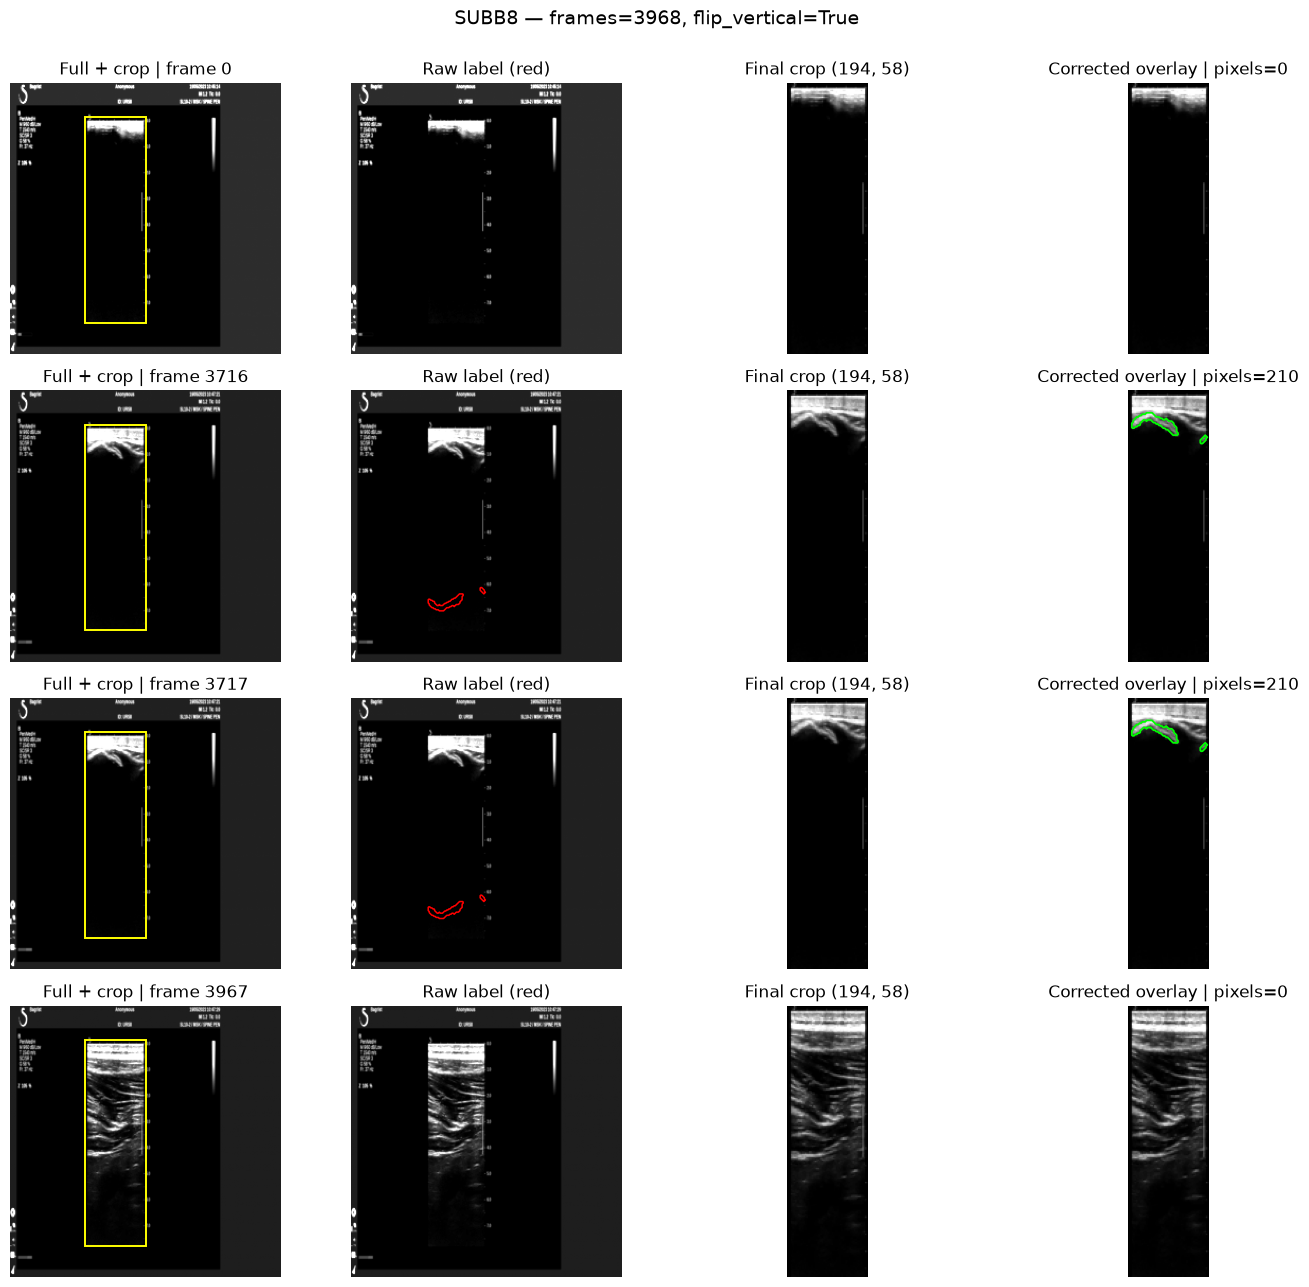

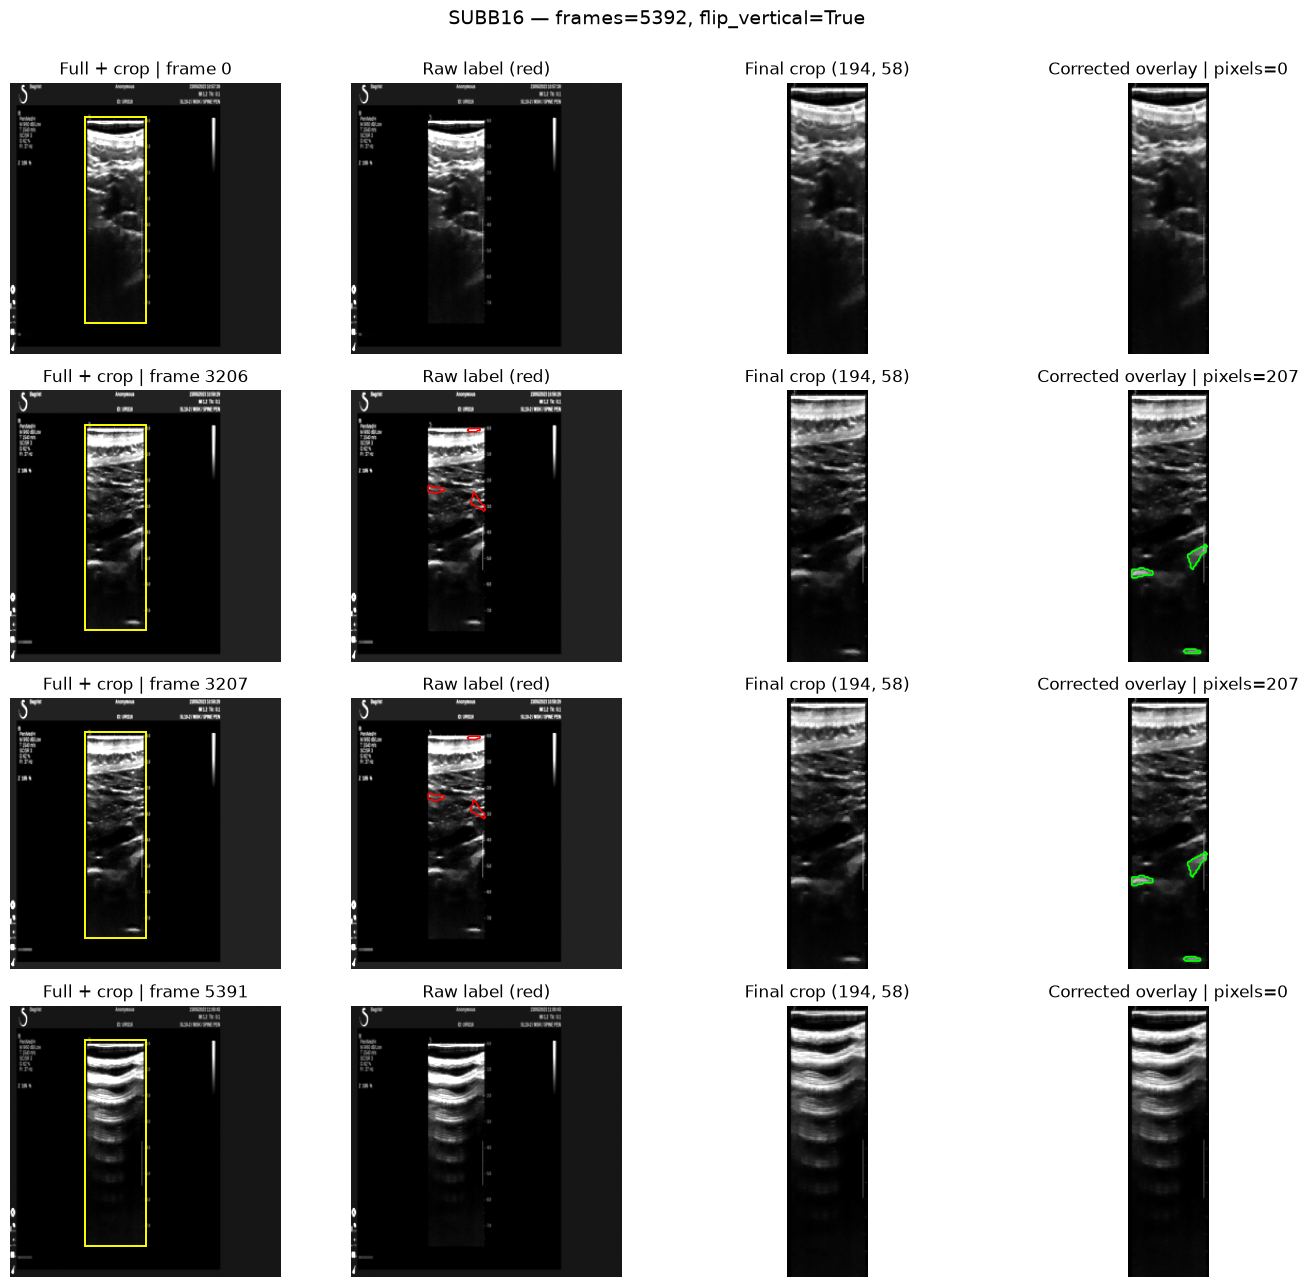

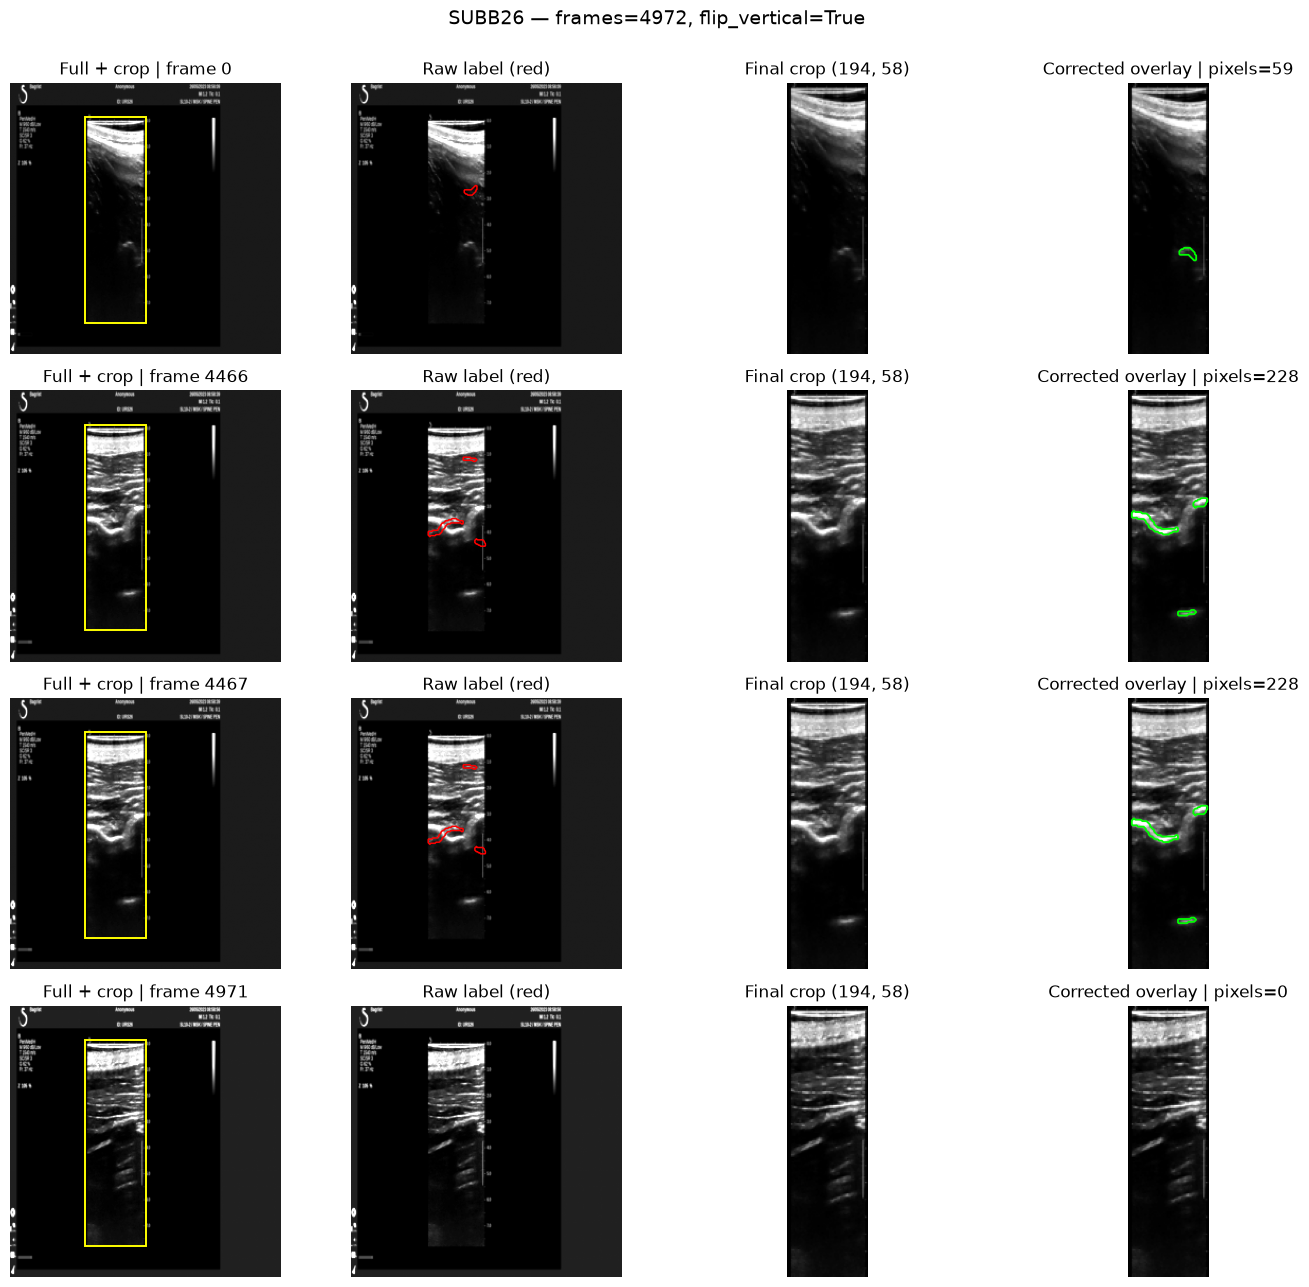

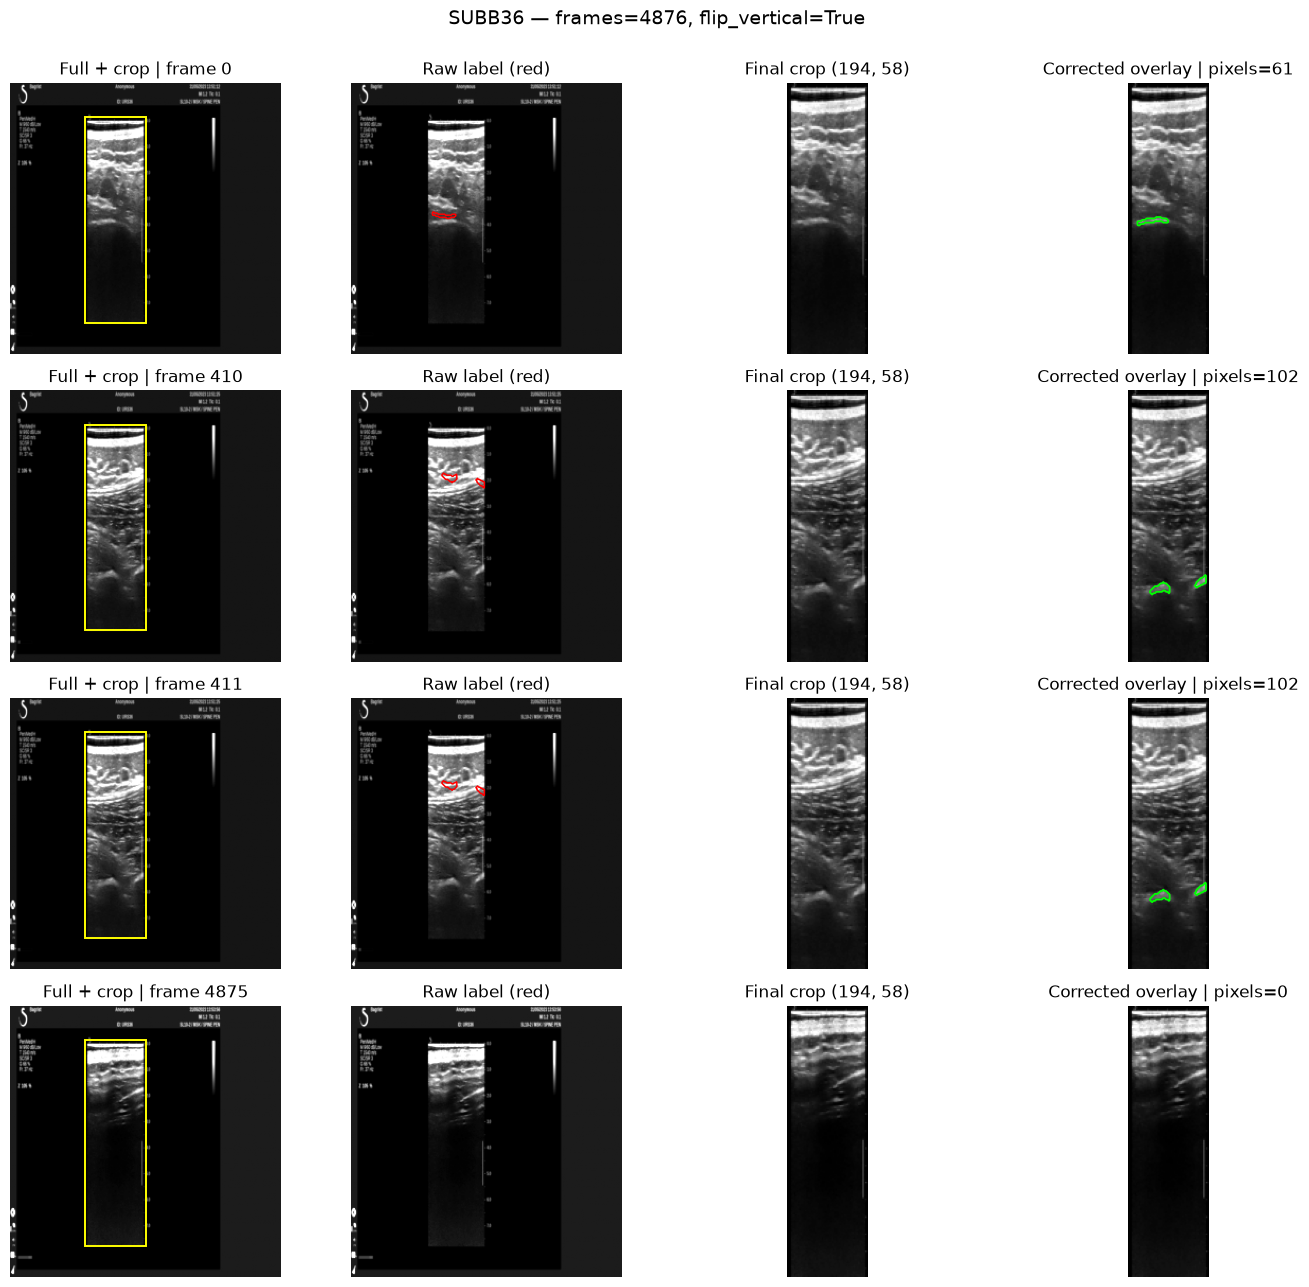

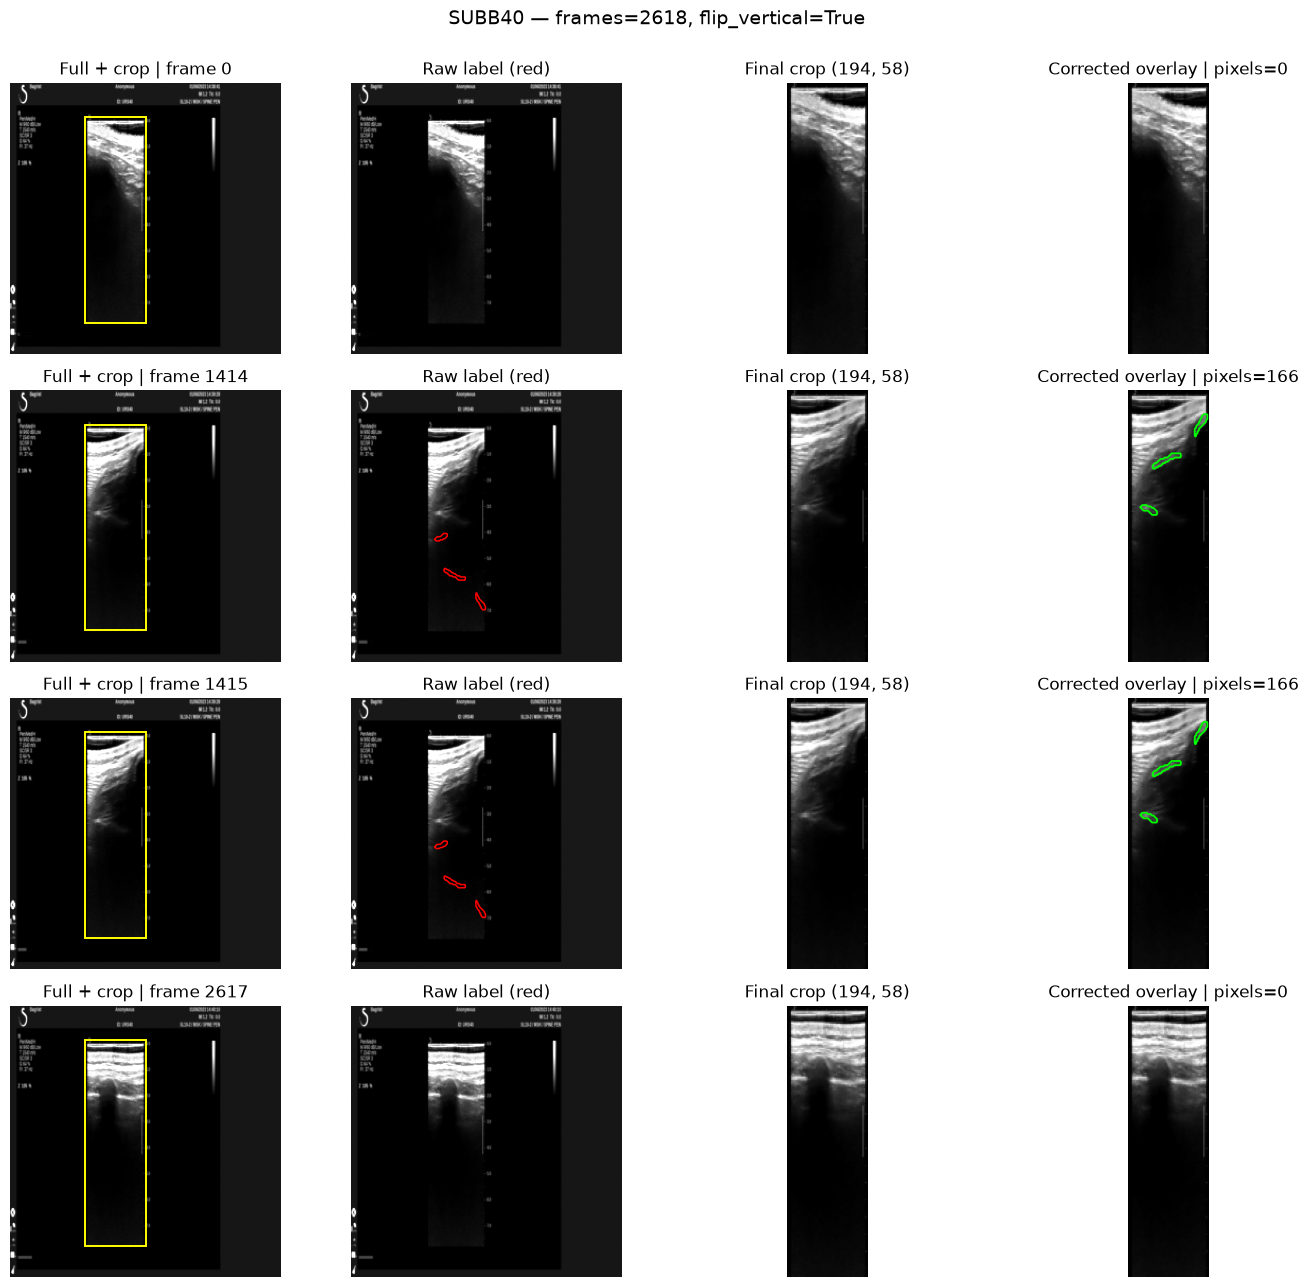

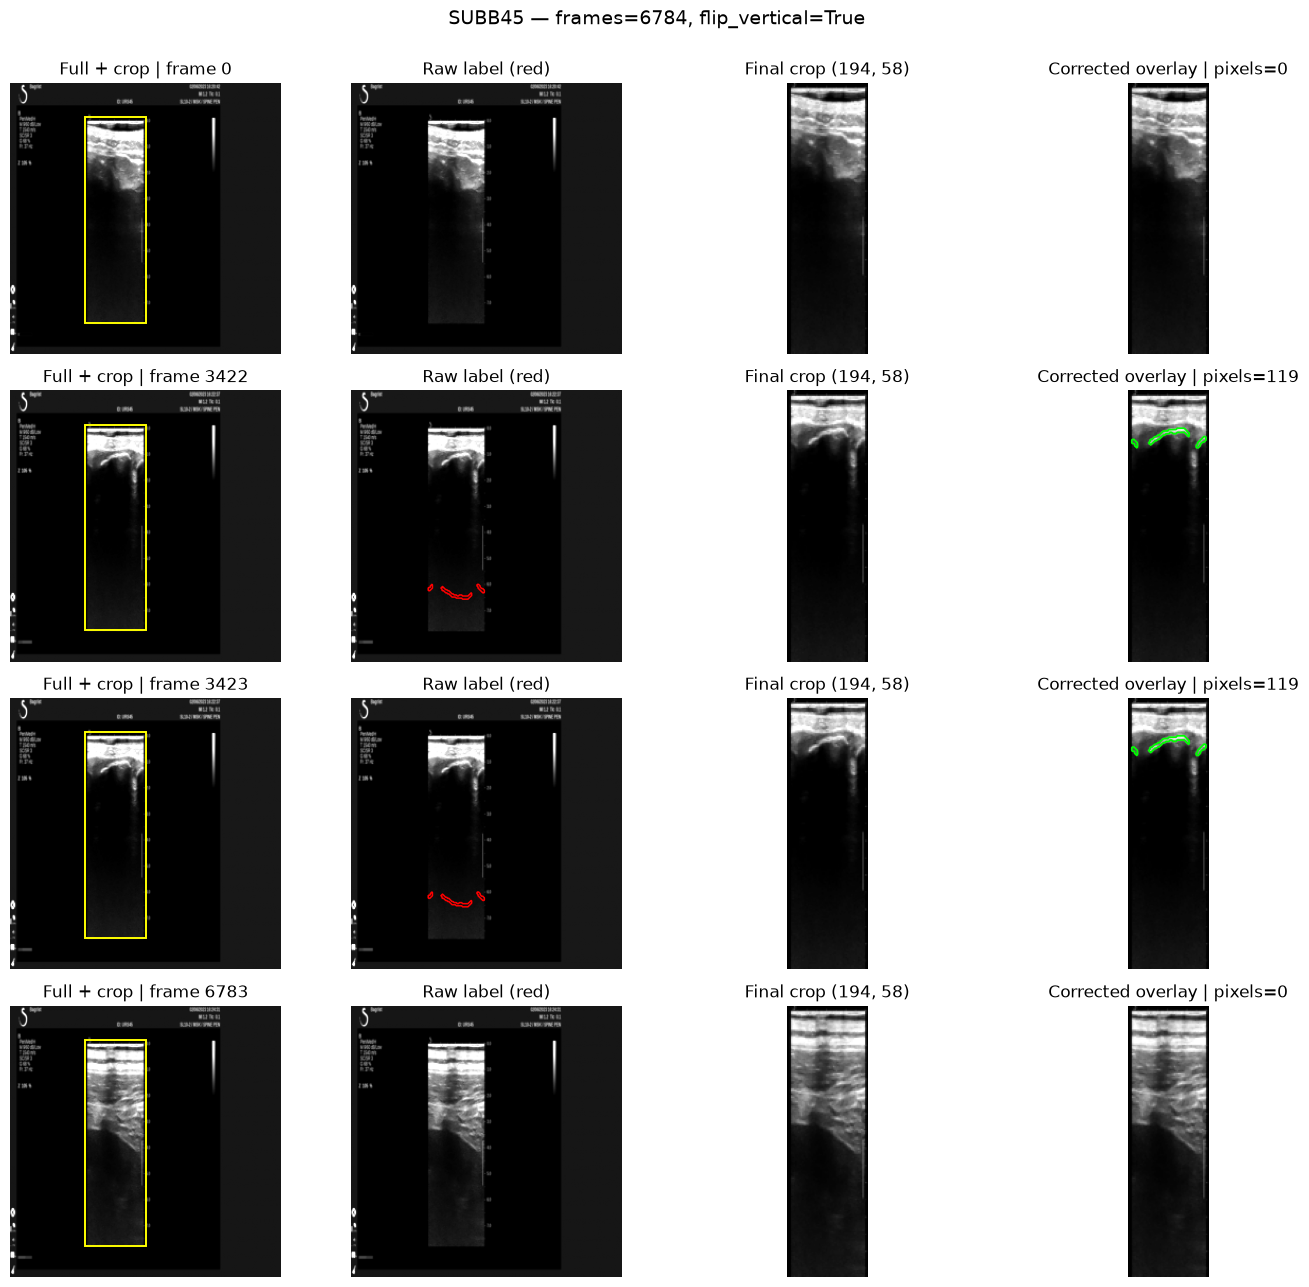

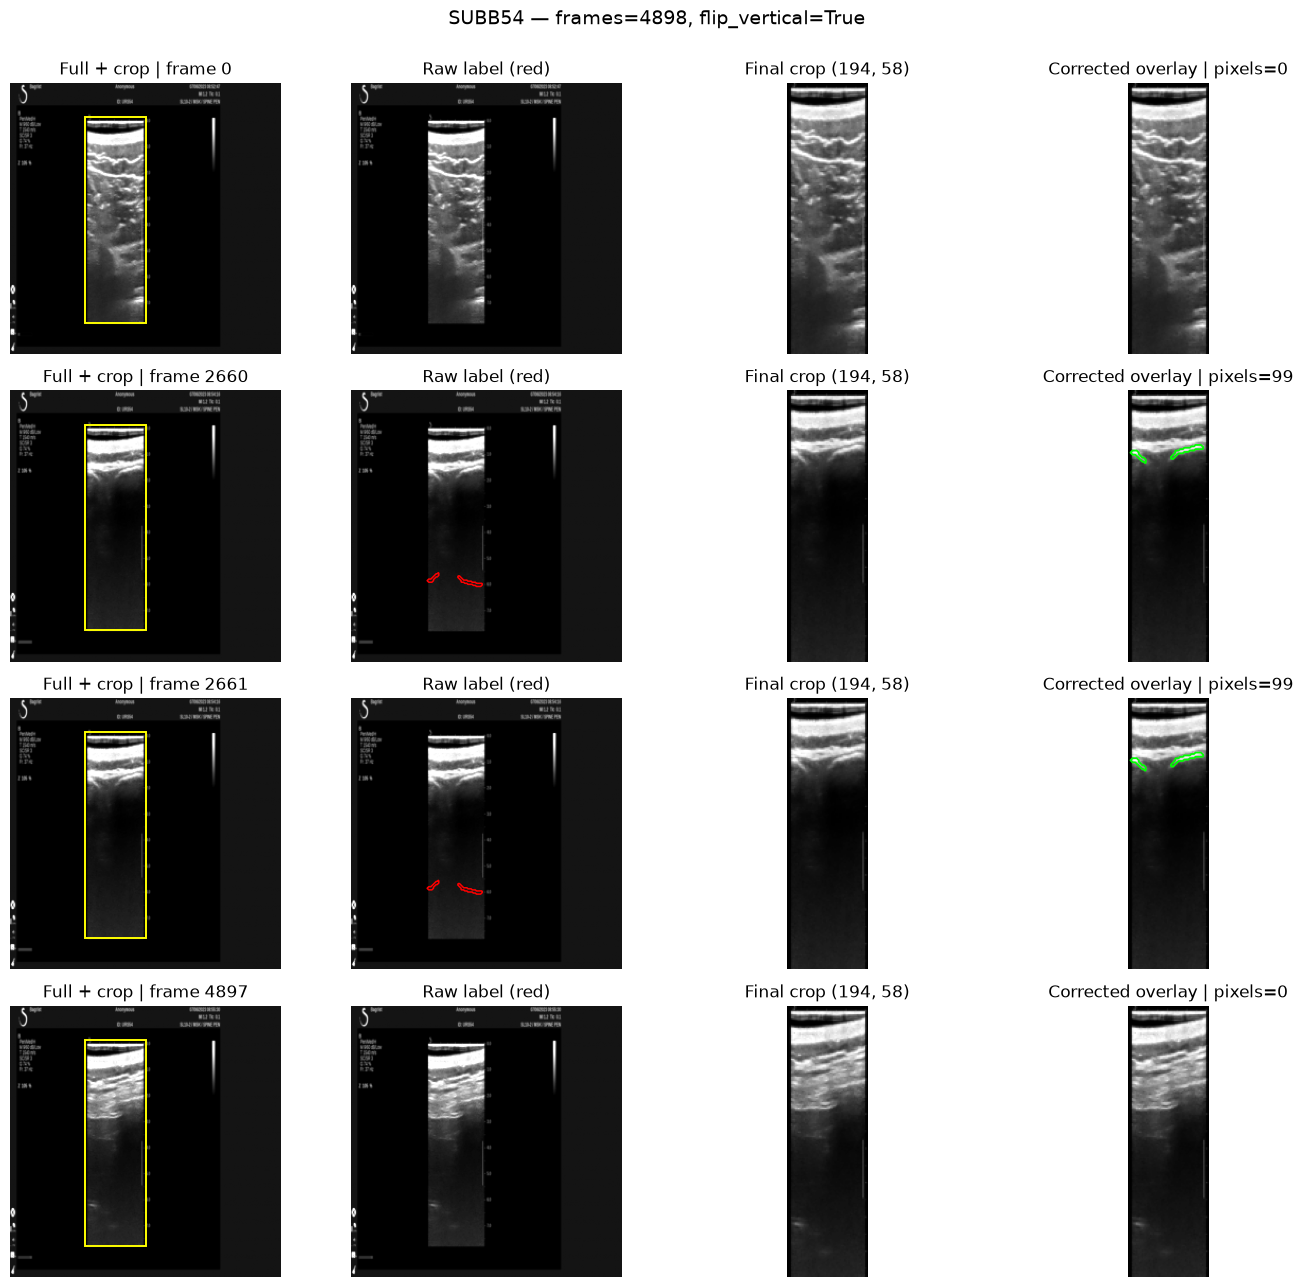

In [7]:
def choose_qa_frames(subject, n=QA_FRAMES_PER_SUBJECT):
    counts = MASK_PIXEL_COUNTS[subject]
    n_frames = len(counts)
    spread = np.linspace(0, n_frames - 1, max(2, n // 2), dtype=int)
    nonempty = np.flatnonzero(counts > 0)
    if len(nonempty):
        top = nonempty[np.argsort(counts[nonempty])[-max(2, n - len(spread)):]]
        chosen = np.unique(np.concatenate([spread, top]))
    else:
        chosen = np.unique(spread)
    if len(chosen) > n:
        chosen = chosen[np.linspace(0, len(chosen) - 1, n, dtype=int)]
    return np.sort(chosen)


def robust_limits(image):
    lo, hi = np.percentile(image, [1, 99])
    if hi <= lo:
        hi = lo + 1e-6
    return lo, hi


def plot_subject_qa(subject, n=QA_FRAMES_PER_SUBJECT):
    frames = choose_qa_frames(subject, n)
    cfg = SUBJECT_CONFIG[subject]
    c = cfg["crop"]
    fig, axes = plt.subplots(len(frames), 4, figsize=(14, 3.2 * len(frames)), squeeze=False)

    for row, idx in enumerate(frames):
        crop_img, crop_mask, full_img, raw_soft, corrected_soft = preprocess_frame(
            subject, int(idx), return_details=True
        )
        raw_mask = raw_soft >= infer_mask_threshold(subject)
        lo, hi = robust_limits(full_img)
        clo, chi = robust_limits(crop_img)

        axes[row, 0].imshow(full_img, cmap="gray", vmin=lo, vmax=hi)
        axes[row, 0].add_patch(Rectangle(
            (c["x1"], c["y1"]), c["x2"] - c["x1"], c["y2"] - c["y1"],
            edgecolor="yellow", facecolor="none", linewidth=1.4
        ))
        axes[row, 0].set_title(f"Full + crop | frame {idx}")

        axes[row, 1].imshow(full_img, cmap="gray", vmin=lo, vmax=hi)
        if raw_mask.any():
            axes[row, 1].contour(raw_mask.astype(float), levels=[0.5], colors="red", linewidths=1.1)
        axes[row, 1].set_title("Raw label (red)")

        axes[row, 2].imshow(crop_img, cmap="gray", vmin=clo, vmax=chi)
        axes[row, 2].set_title(f"Final crop {crop_img.shape}")

        axes[row, 3].imshow(crop_img, cmap="gray", vmin=clo, vmax=chi)
        if crop_mask.any():
            axes[row, 3].contour(crop_mask.astype(float), levels=[0.5], colors="lime", linewidths=1.3)
        axes[row, 3].set_title(f"Corrected overlay | pixels={int(crop_mask.sum())}")

        for ax in axes[row]:
            ax.axis("off")

    fig.suptitle(
        f"{subject} — frames={len(DATA[subject]['recordings'])}, "
        f"flip_vertical={cfg['flip_mask_vertical']}", y=1.002, fontsize=14
    )
    plt.tight_layout()
    plt.show()


for subject in SUBJECTS:
    plot_subject_qa(subject)

## 7. Confirmed preprocessing configuration

The common crop and vertical mask correction are already confirmed for all seven subjects, so export proceeds automatically. The QA plots remain as an integrity record.

In [8]:
# The transformation was already confirmed for all seven uploaded subjects.
# No manual approval switch is required in this one-click notebook.
print("Preprocessing configuration: confirmed for all seven subjects")


Preprocessing configuration: confirmed for all seven subjects


## 8. Chunked export

This creates one image array and one mask array per subject without holding a full subject in RAM. Metadata records source paths, frame counts, crop, orientation, scale, and threshold.

In [9]:
def export_subject(subject, output_root=OUTPUT_ROOT, chunk_size=CHUNK_SIZE):
    output_root.mkdir(parents=True, exist_ok=True)
    n = len(DATA[subject]["recordings"])
    c = SUBJECT_CONFIG[subject]["crop"]
    out_shape = (n, c["y2"] - c["y1"], c["x2"] - c["x1"])

    image_path = output_root / f"{subject}_images.npy"
    mask_path = output_root / f"{subject}_masks.npy"
    images_out = open_memmap(image_path, mode="w+", dtype=np.float32, shape=out_shape)
    masks_out = open_memmap(mask_path, mode="w+", dtype=np.uint8, shape=out_shape)

    for start in range(0, n, chunk_size):
        end = min(start + chunk_size, n)
        for idx in range(start, end):
            images_out[idx], masks_out[idx] = preprocess_frame(subject, idx)
        images_out.flush()
        masks_out.flush()
        print(f"{subject}: {end}/{n}", end="\r")

    del images_out, masks_out
    metadata = {
        "subject": subject,
        "frames": n,
        "output_shape": list(out_shape),
        "image_dtype": "float32",
        "image_range": [0.0, 1.0],
        "mask_dtype": "uint8",
        "mask_values": [0, 1],
        "crop": c,
        "flip_mask_vertical": SUBJECT_CONFIG[subject]["flip_mask_vertical"],
        "image_scale": infer_image_scale(subject),
        "mask_threshold": infer_mask_threshold(subject),
        "source_recordings": str(FILE_PAIRS[subject][0]),
        "source_labels": str(FILE_PAIRS[subject][1]),
        "diagnostics": diagnostics.loc[subject].to_dict(),
    }
    metadata_path = output_root / f"{subject}_metadata.json"
    metadata_path.write_text(json.dumps(metadata, indent=2), encoding="utf-8")
    print(f"{subject}: exported to {output_root}")
    return image_path, mask_path, metadata_path


exported_files = {subject: export_subject(subject) for subject in SUBJECTS}
diagnostics.to_csv(OUTPUT_ROOT / "all_subjects_diagnostics.csv")
inventory.to_csv(OUTPUT_ROOT / "all_subjects_inventory.csv")
print("All exports complete:", OUTPUT_ROOT)

SUBB8: exported to /kaggle/working/subb_preprocessed_194x58
SUBB16: exported to /kaggle/working/subb_preprocessed_194x58
SUBB26: exported to /kaggle/working/subb_preprocessed_194x58
SUBB36: exported to /kaggle/working/subb_preprocessed_194x58
SUBB40: exported to /kaggle/working/subb_preprocessed_194x58
SUBB45: exported to /kaggle/working/subb_preprocessed_194x58
SUBB54: exported to /kaggle/working/subb_preprocessed_194x58
All exports complete: /kaggle/working/subb_preprocessed_194x58


## 9. Verify saved arrays and plot exported samples

This final check reopens every exported array with memory mapping, verifies its shape/type/range, and plots three saved overlays per subject.

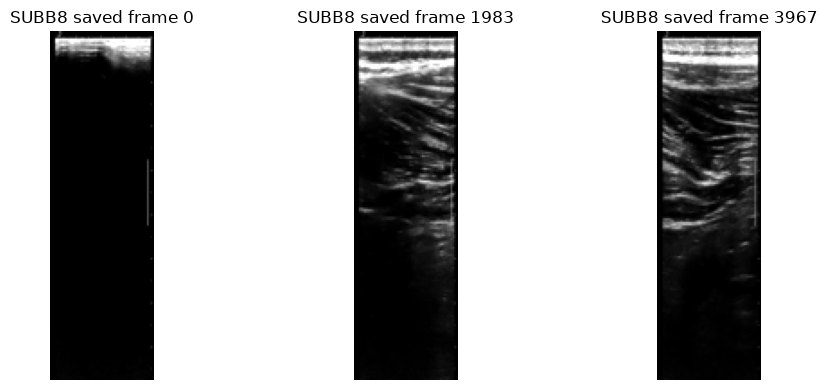

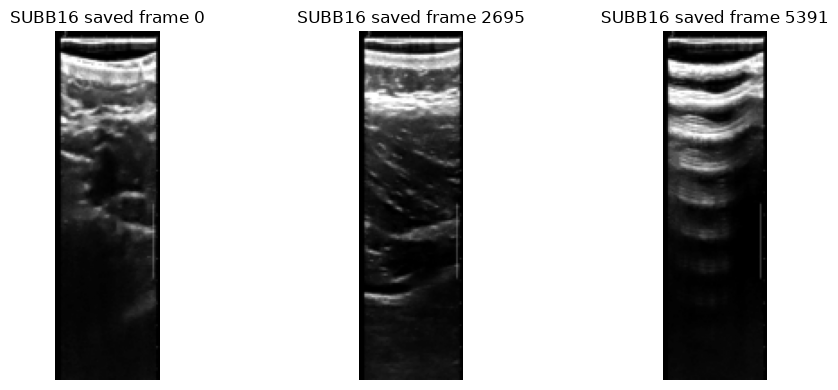

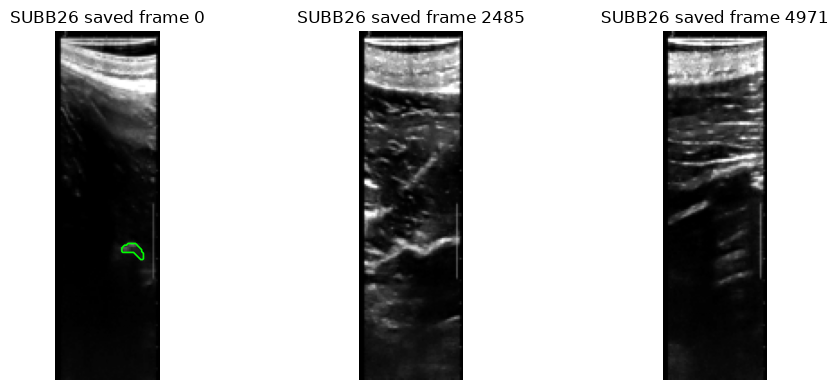

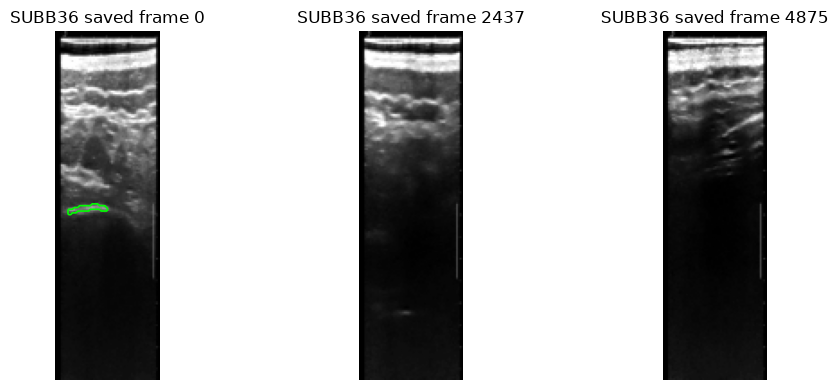

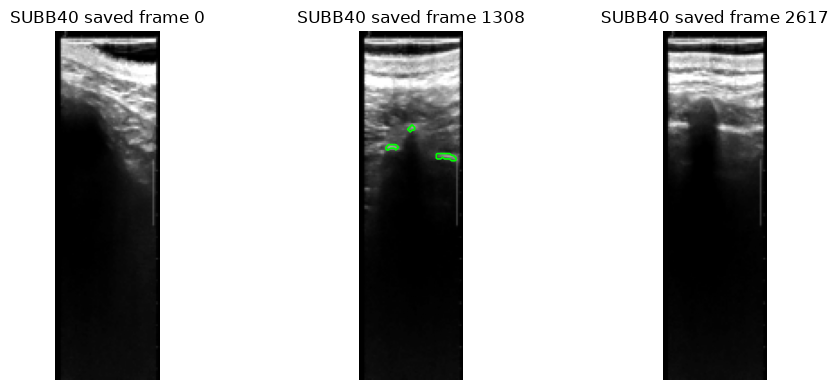

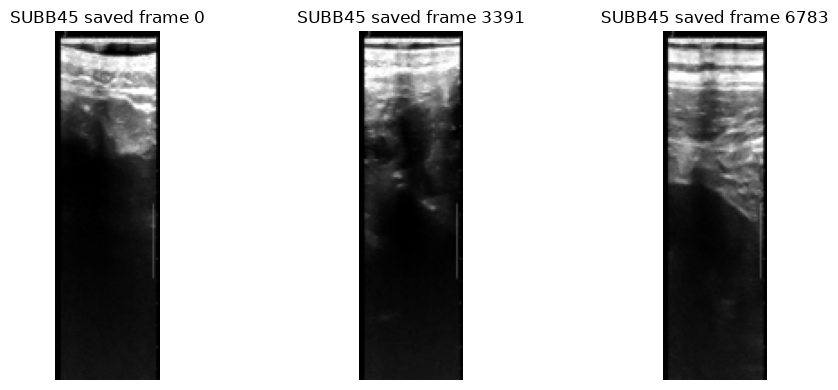

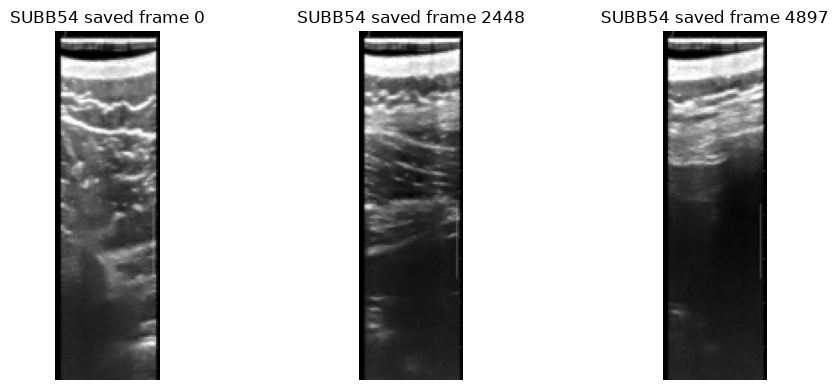

,saved_shape,status
subject,,
SUBB8,"(3968, 194, 58)",PASS
SUBB16,"(5392, 194, 58)",PASS
SUBB26,"(4972, 194, 58)",PASS
SUBB36,"(4876, 194, 58)",PASS
SUBB40,"(2618, 194, 58)",PASS
SUBB45,"(6784, 194, 58)",PASS
SUBB54,"(4898, 194, 58)",PASS


In [10]:
verification_rows = []
for subject in SUBJECTS:
    image_path, mask_path, _ = exported_files[subject]
    images = np.load(image_path, mmap_mode="r", allow_pickle=False)
    masks = np.load(mask_path, mmap_mode="r", allow_pickle=False)
    expected_frames = len(DATA[subject]["recordings"])
    assert images.shape == masks.shape == (expected_frames, EXPECTED_H, EXPECTED_W)
    assert images.dtype == np.float32 and masks.dtype == np.uint8

    idxs = np.unique(np.linspace(0, expected_frames - 1, 3, dtype=int))
    sample_images = np.asarray(images[idxs])
    sample_masks = np.asarray(masks[idxs])
    assert np.isfinite(sample_images).all()
    assert sample_images.min() >= 0 and sample_images.max() <= 1
    assert set(np.unique(sample_masks)).issubset({0, 1})

    verification_rows.append({"subject": subject, "saved_shape": str(images.shape), "status": "PASS"})
    fig, axes = plt.subplots(1, len(idxs), figsize=(3.6 * len(idxs), 4), squeeze=False)
    for ax, idx, image, mask in zip(axes[0], idxs, sample_images, sample_masks):
        lo, hi = robust_limits(image)
        ax.imshow(image, cmap="gray", vmin=lo, vmax=hi)
        if mask.any():
            ax.contour(mask.astype(float), levels=[0.5], colors="lime", linewidths=1.2)
        ax.set_title(f"{subject} saved frame {idx}")
        ax.axis("off")
    plt.tight_layout()
    plt.show()

display(pd.DataFrame(verification_rows).set_index("subject"))

## Interpretation checklist

- `frames` must match between recordings and labels for every subject.
- The yellow crop rectangle must contain the complete ultrasound region you intend to retain.
- The final green contour must follow the target anatomy across early, middle, late, and high-annotation frames.
- `foreground_retained_percent` should ideally be at least 99%.
- Frequent mask contact with a crop edge is a warning that the crop may be too tight.
- If raw red contours align better than corrected green contours for one subject, set only that subject's `flip_mask_vertical` to `False`, rerun diagnostics/plots, and re-check.
- Do not confirm or export a subject based on shape equality alone.

## 2. Load the verified arrays and define the seven LOSO folds

Each subject becomes the test subject exactly once. No frame from that subject enters its fold's training stream. Training length is fixed in advance, so test performance cannot affect stopping.


In [11]:
PROCESSED = {}
processed_rows = []
for subject in SUBJECTS:
    image_path = PREPROCESSING_ROOT / f"{subject}_images.npy"
    mask_path = PREPROCESSING_ROOT / f"{subject}_masks.npy"
    images = np.load(image_path, mmap_mode="r", allow_pickle=False)
    masks = np.load(mask_path, mmap_mode="r", allow_pickle=False)
    if images.shape != masks.shape or images.shape[1:] != ORIGINAL_SHAPE:
        raise ValueError(f"{subject}: invalid processed shapes {images.shape}, {masks.shape}")
    if images.dtype != np.float32 or masks.dtype != np.uint8:
        raise ValueError(f"{subject}: expected float32 images and uint8 masks")
    PROCESSED[subject] = {
        "images": images,
        "masks": masks,
        "image_path": image_path,
        "mask_path": mask_path,
    }
    processed_rows.append({"subject": subject, "frames": len(images), "shape": str(images.shape)})

processed_inventory = pd.DataFrame(processed_rows).set_index("subject")
display(processed_inventory)
print("Total processed frames:", int(processed_inventory.frames.sum()))

FOLDS = []
for fold_index, test_subject in enumerate(SUBJECTS):
    train_subjects = [subject for subject in SUBJECTS if subject != test_subject]
    FOLDS.append({
        "fold": fold_index,
        "train_subjects": train_subjects,
        "test_subject": test_subject,
        "train_frames": int(sum(len(PROCESSED[s]["images"]) for s in train_subjects)),
        "test_frames": int(len(PROCESSED[test_subject]["images"])),
    })

fold_table = pd.DataFrame(FOLDS)
display(fold_table)
(WORK_ROOT / "loso_folds.json").write_text(json.dumps(FOLDS, indent=2), encoding="utf-8")

for fold in FOLDS:
    assert fold["test_subject"] not in fold["train_subjects"]
    assert set(fold["train_subjects"]) | {fold["test_subject"]} == set(SUBJECTS)
print("LOSO leakage audit passed")


,frames,shape
subject,,
SUBB8,3968,"(3968, 194, 58)"
SUBB16,5392,"(5392, 194, 58)"
SUBB26,4972,"(4972, 194, 58)"
SUBB36,4876,"(4876, 194, 58)"
SUBB40,2618,"(2618, 194, 58)"
SUBB45,6784,"(6784, 194, 58)"
SUBB54,4898,"(4898, 194, 58)"


Total processed frames: 33508


,fold,train_subjects,test_subject,train_frames,test_frames
0,0,"[SUBB16, SUBB26, SUBB36, SUBB40, SUBB45, SUBB54]",SUBB8,29540,3968
1,1,"[SUBB8, SUBB26, SUBB36, SUBB40, SUBB45, SUBB54]",SUBB16,28116,5392
2,2,"[SUBB8, SUBB16, SUBB36, SUBB40, SUBB45, SUBB54]",SUBB26,28536,4972
3,3,"[SUBB8, SUBB16, SUBB26, SUBB40, SUBB45, SUBB54]",SUBB36,28632,4876
4,4,"[SUBB8, SUBB16, SUBB26, SUBB36, SUBB45, SUBB54]",SUBB40,30890,2618
5,5,"[SUBB8, SUBB16, SUBB26, SUBB36, SUBB40, SUBB54]",SUBB45,26724,6784
6,6,"[SUBB8, SUBB16, SUBB26, SUBB36, SUBB40, SUBB45]",SUBB54,28610,4898


LOSO leakage audit passed


## 3. Convert the processed arrays to sharded TFRecords

Python generators and random NumPy reads often starve a TPU. This one-time conversion stores the frame index, image, and mask in TFRecords and separates positive from empty masks. The training pipeline can then balance subjects and mask classes entirely with `tf.data`.


In [12]:
def _bytes_feature(value):
    return tf.train.Feature(bytes_list=tf.train.BytesList(value=[value]))


def _int_feature(value):
    return tf.train.Feature(int64_list=tf.train.Int64List(value=[int(value)]))


def serialize_example(image, mask, frame_index):
    example = tf.train.Example(features=tf.train.Features(feature={
        "image": _bytes_feature(np.asarray(image, dtype=np.float32).tobytes(order="C")),
        "mask": _bytes_feature(np.asarray(mask, dtype=np.uint8).tobytes(order="C")),
        "frame": _int_feature(frame_index),
    }))
    return example.SerializeToString()


def write_class_shards(subject, class_name, indices, shard_count=TFRECORD_SHARDS_PER_CLASS):
    subject_dir = TFRECORD_ROOT / subject
    subject_dir.mkdir(parents=True, exist_ok=True)
    indices = np.asarray(indices, dtype=np.int64)
    if not len(indices):
        return []
    shard_count = min(shard_count, len(indices))
    paths = [subject_dir / f"{class_name}-{i:02d}-of-{shard_count:02d}.tfrecord"
             for i in range(shard_count)]
    writers = [tf.io.TFRecordWriter(str(path)) for path in paths]
    try:
        for position, frame_index in enumerate(indices):
            image = PROCESSED[subject]["images"][int(frame_index)]
            mask = PROCESSED[subject]["masks"][int(frame_index)]
            writers[position % shard_count].write(
                serialize_example(image, mask, int(frame_index))
            )
    finally:
        for writer in writers:
            writer.close()
    return paths


TFRECORD_MANIFEST = {}
tfrecord_rows = []
conversion_start = time.perf_counter()
for subject in SUBJECTS:
    # Remove only stale TFRecord shards for this exact subject.
    subject_dir = TFRECORD_ROOT / subject
    subject_dir.mkdir(parents=True, exist_ok=True)
    for stale in subject_dir.glob("*.tfrecord"):
        stale.unlink()

    masks = PROCESSED[subject]["masks"]
    foreground_counts = np.zeros(len(masks), dtype=np.int64)
    for start in range(0, len(masks), 256):
        end = min(start + 256, len(masks))
        foreground_counts[start:end] = np.asarray(masks[start:end]).sum(axis=(1, 2))
    positive_indices = np.flatnonzero(foreground_counts > 0)
    empty_indices = np.flatnonzero(foreground_counts == 0)

    positive_files = write_class_shards(subject, "positive", positive_indices)
    empty_files = write_class_shards(subject, "empty", empty_indices)
    if not positive_files:
        warnings.warn(f"{subject} has no positive masks; class balancing will use empty frames only")
    if not empty_files:
        warnings.warn(f"{subject} has no empty masks; class balancing will use positive frames only")

    TFRECORD_MANIFEST[subject] = {
        "positive": [str(path) for path in positive_files],
        "empty": [str(path) for path in empty_files],
        "positive_count": int(len(positive_indices)),
        "empty_count": int(len(empty_indices)),
    }
    tfrecord_rows.append({
        "subject": subject,
        "positive": len(positive_indices),
        "empty": len(empty_indices),
        "files": len(positive_files) + len(empty_files),
    })
    print(subject, "TFRecords complete")

(TFRECORD_ROOT / "manifest.json").write_text(
    json.dumps(TFRECORD_MANIFEST, indent=2), encoding="utf-8"
)
display(pd.DataFrame(tfrecord_rows).set_index("subject"))
print(f"TFRecord conversion: {(time.perf_counter() - conversion_start) / 60:.1f} min")


SUBB8 TFRecords complete
SUBB16 TFRecords complete
SUBB26 TFRecords complete
SUBB36 TFRecords complete
SUBB40 TFRecords complete
SUBB45 TFRecords complete
SUBB54 TFRecords complete


,positive,empty,files
subject,,,
SUBB8,582,3386,8
SUBB16,604,4788,8
SUBB26,600,4372,8
SUBB36,706,4170,8
SUBB40,710,1908,8
SUBB45,762,6022,8
SUBB54,680,4218,8


TFRecord conversion: 0.1 min


## 4. TPU-native balanced input pipeline


In [14]:
FEATURE_SPEC = {
    "image": tf.io.FixedLenFeature([], tf.string),
    "mask": tf.io.FixedLenFeature([], tf.string),
    "frame": tf.io.FixedLenFeature([], tf.int64),
}
PAD_TOP = (MODEL_SHAPE[0] - ORIGINAL_SHAPE[0]) // 2
PAD_BOTTOM = MODEL_SHAPE[0] - ORIGINAL_SHAPE[0] - PAD_TOP
PAD_LEFT = (MODEL_SHAPE[1] - ORIGINAL_SHAPE[1]) // 2
PAD_RIGHT = MODEL_SHAPE[1] - ORIGINAL_SHAPE[1] - PAD_LEFT


def decode_record(serialized):
    item = tf.io.parse_single_example(serialized, FEATURE_SPEC)
    image = tf.reshape(tf.io.decode_raw(item["image"], tf.float32), ORIGINAL_SHAPE)
    mask = tf.reshape(tf.io.decode_raw(item["mask"], tf.uint8), ORIGINAL_SHAPE)
    image = tf.clip_by_value(image, 0.0, 1.0)[..., None]
    mask = tf.cast(mask > 0, tf.float32)[..., None]
    image = tf.pad(image, [[PAD_TOP, PAD_BOTTOM], [PAD_LEFT, PAD_RIGHT], [0, 0]])
    mask = tf.pad(mask, [[PAD_TOP, PAD_BOTTOM], [PAD_LEFT, PAD_RIGHT], [0, 0]])
    image = tf.ensure_shape(image, (*MODEL_SHAPE, 1))
    mask = tf.ensure_shape(mask, (*MODEL_SHAPE, 1))
    return image, mask, item["frame"]


def augment_pair(image, mask):
    do_flip = tf.random.uniform(()) < 0.5
    image = tf.cond(do_flip, lambda: tf.image.flip_left_right(image), lambda: image)
    mask = tf.cond(do_flip, lambda: tf.image.flip_left_right(mask), lambda: mask)

    gamma = tf.random.uniform((), 0.85, 1.15)
    gain = tf.random.uniform((), 0.90, 1.10)
    image = gain * tf.pow(tf.clip_by_value(image, 1e-6, 1.0), gamma)
    noise = tf.random.normal(tf.shape(image), stddev=0.01)
    image = tf.cond(tf.random.uniform(()) < 0.3, lambda: image + noise, lambda: image)
    return tf.clip_by_value(image, 0.0, 1.0), mask


def repeated_serialized_stream(files, count, seed):
    if not files or count <= 0:
        return None
    dataset = tf.data.TFRecordDataset(files, num_parallel_reads=tf.data.AUTOTUNE)
    dataset = dataset.shuffle(min(int(count), 8192), seed=seed, reshuffle_each_iteration=True)
    return dataset.repeat()


def subject_stream(subject, seed):
    manifest = TFRECORD_MANIFEST[subject]
    positive = repeated_serialized_stream(
        manifest["positive"], manifest["positive_count"], seed + 1
    )
    empty = repeated_serialized_stream(
        manifest["empty"], manifest["empty_count"], seed + 2
    )
    if positive is not None and empty is not None:
        return tf.data.Dataset.sample_from_datasets(
            [positive, empty],
            weights=[POSITIVE_FRACTION, 1.0 - POSITIVE_FRACTION],
            seed=seed,
            stop_on_empty_dataset=False,
        )
    return positive if positive is not None else empty


def make_training_dataset(train_subjects, fold_seed):
    streams = [subject_stream(subject, fold_seed + 100 * i)
               for i, subject in enumerate(train_subjects)]
    dataset = tf.data.Dataset.sample_from_datasets(
        streams,
        weights=[1.0 / len(streams)] * len(streams),
        seed=fold_seed,
        stop_on_empty_dataset=False,
    )
    dataset = dataset.map(decode_record, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.map(
        lambda image, mask, frame: augment_pair(image, mask),
        num_parallel_calls=tf.data.AUTOTUNE,
        deterministic=False,
    )
    options = tf.data.Options()
    options.experimental_deterministic = False
    dataset = dataset.with_options(options)
    return dataset.batch(GLOBAL_BATCH_SIZE, drop_remainder=True).prefetch(tf.data.AUTOTUNE)


def evaluation_serialized_dataset(subject):
    files = TFRECORD_MANIFEST[subject]["positive"] + TFRECORD_MANIFEST[subject]["empty"]
    dataset = tf.data.TFRecordDataset(files, num_parallel_reads=1)
    return dataset.map(decode_record, num_parallel_calls=tf.data.AUTOTUNE, deterministic=True)


# Decode one batch before training and verify TPU input shapes and mask values.
probe_fold = FOLDS[0]
probe_batch = next(iter(make_training_dataset(probe_fold["train_subjects"], SEED).take(1)))
probe_images, probe_masks = probe_batch
assert probe_images.shape == (GLOBAL_BATCH_SIZE, *MODEL_SHAPE, 1)
assert probe_masks.shape == probe_images.shape
assert set(np.unique(probe_masks.numpy())).issubset({0.0, 1.0})
print("Input-pipeline test passed:", probe_images.shape, probe_images.dtype)


Input-pipeline test passed: (128, 208, 64, 1) <dtype: 'float32'>


## 5. Basic U-Net and fixed objective

This is a conventional four-level 2D U-Net with batch normalization. The objective is binary cross-entropy plus soft Dice loss. The final sigmoid is explicitly float32 even though TPU compute uses bfloat16.


In [15]:
def dice_coefficient_tf(y_true, y_pred, smooth=1.0):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    axes = tuple(range(1, len(y_true.shape)))
    intersection = tf.reduce_sum(y_true * y_pred, axis=axes)
    denominator = tf.reduce_sum(y_true, axis=axes) + tf.reduce_sum(y_pred, axis=axes)
    return tf.reduce_mean((2.0 * intersection + smooth) / (denominator + smooth))


def bce_dice_loss(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    bce = tf.reduce_mean(tf.keras.losses.binary_crossentropy(y_true, y_pred))
    return bce + (1.0 - dice_coefficient_tf(y_true, y_pred))


def conv_block(x, filters):
    for _ in range(2):
        x = tf.keras.layers.Conv2D(filters, 3, padding="same", use_bias=False)(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.Activation("relu")(x)
    return x


def build_basic_unet(base_filters=BASE_FILTERS):
    inputs = tf.keras.Input((*MODEL_SHAPE, 1), name="ultrasound")
    skips = []
    x = inputs
    for filters in [base_filters, base_filters * 2, base_filters * 4, base_filters * 8]:
        x = conv_block(x, filters)
        skips.append(x)
        x = tf.keras.layers.MaxPool2D(2)(x)
    x = conv_block(x, base_filters * 16)
    for filters, skip in zip(
        [base_filters * 8, base_filters * 4, base_filters * 2, base_filters],
        reversed(skips),
    ):
        x = tf.keras.layers.Conv2DTranspose(filters, 2, strides=2, padding="same")(x)
        x = tf.keras.layers.Concatenate()([x, skip])
        x = conv_block(x, filters)
    outputs = tf.keras.layers.Conv2D(1, 1, activation="sigmoid", dtype="float32", name="mask")(x)
    return tf.keras.Model(inputs, outputs, name="basic_unet")


with STRATEGY.scope():
    architecture_check = build_basic_unet()
assert architecture_check.output_shape[1:3] == MODEL_SHAPE
print("U-Net parameters:", f"{architecture_check.count_params():,}")
del architecture_check


I0000 00:00:1788381598.983468     592 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


U-Net parameters: 7,768,353


## 6. Leakage-safe evaluation functions


In [16]:
def confusion_counts(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=bool)
    y_pred = np.asarray(y_pred, dtype=bool)
    tp = int(np.logical_and(y_true, y_pred).sum())
    fp = int(np.logical_and(~y_true, y_pred).sum())
    fn = int(np.logical_and(y_true, ~y_pred).sum())
    tn = int(np.logical_and(~y_true, ~y_pred).sum())
    return tp, fp, fn, tn


def overlap_from_counts(tp, fp, fn):
    dice_den = 2 * tp + fp + fn
    iou_den = tp + fp + fn
    dice = 1.0 if dice_den == 0 else 2 * tp / dice_den
    iou = 1.0 if iou_den == 0 else tp / iou_den
    precision = 1.0 if tp + fp == 0 and tp + fn == 0 else tp / max(tp + fp, 1)
    recall = 1.0 if tp + fn == 0 else tp / (tp + fn)
    return dice, iou, precision, recall


def hd95_binary(y_true, y_pred):
    from scipy.ndimage import binary_erosion, distance_transform_edt
    y_true = np.asarray(y_true, dtype=bool)
    y_pred = np.asarray(y_pred, dtype=bool)
    if not y_true.any() or not y_pred.any():
        return np.nan
    true_surface = y_true ^ binary_erosion(y_true)
    pred_surface = y_pred ^ binary_erosion(y_pred)
    dist_to_true = distance_transform_edt(~true_surface)
    dist_to_pred = distance_transform_edt(~pred_surface)
    distances = np.concatenate([dist_to_true[pred_surface], dist_to_pred[true_surface]])
    return float(np.percentile(distances, 95)) if len(distances) else np.nan


def evaluate_subject(subject, prediction_masks):
    truth = np.asarray(PROCESSED[subject]["masks"] > 0, dtype=bool)
    pred = np.asarray(prediction_masks > 0, dtype=bool)
    if pred.shape != truth.shape:
        raise ValueError(f"{subject}: prediction {pred.shape} != truth {truth.shape}")

    frame_rows = []
    for frame_index in range(len(truth)):
        tp, fp, fn, tn = confusion_counts(truth[frame_index], pred[frame_index])
        dice, iou, precision, recall = overlap_from_counts(tp, fp, fn)
        gt_nonempty = bool(truth[frame_index].any())
        pred_nonempty = bool(pred[frame_index].any())
        frame_rows.append({
            "subject": subject,
            "frame": frame_index,
            "gt_nonempty": gt_nonempty,
            "pred_nonempty": pred_nonempty,
            "dice": dice,
            "iou": iou,
            "precision": precision,
            "recall": recall,
            "hd95_pixels": hd95_binary(truth[frame_index], pred[frame_index]),
            "tp": tp, "fp": fp, "fn": fn, "tn": tn,
        })

    frames = pd.DataFrame(frame_rows)
    tp, fp, fn, tn = confusion_counts(truth, pred)
    dice, iou, precision, recall = overlap_from_counts(tp, fp, fn)
    positive = frames.gt_nonempty
    both_positive = frames.gt_nonempty & frames.pred_nonempty
    summary = {
        "model": "basic_unet_tpu",
        "subject": subject,
        "frames": len(truth),
        "subject_micro_dice": dice,
        "subject_micro_iou": iou,
        "subject_micro_precision": precision,
        "subject_micro_recall": recall,
        "mean_frame_dice_all": float(frames.dice.mean()),
        "mean_frame_dice_gt_nonempty": (
            float(frames.loc[positive, "dice"].mean()) if positive.any() else np.nan
        ),
        "mean_hd95_both_nonempty_pixels": (
            float(frames.loc[both_positive, "hd95_pixels"].mean())
            if both_positive.any() else np.nan
        ),
        "gt_nonempty_frames": int(positive.sum()),
        "missed_positive_frames": int((frames.gt_nonempty & ~frames.pred_nonempty).sum()),
        "false_positive_empty_frames": int((~frames.gt_nonempty & frames.pred_nonempty).sum()),
    }
    return frames, summary


## 7. Train and test all seven folds

The loop is automatic. Completed folds with the same experiment signature are skipped if this cell is rerun in the same Kaggle session. After the first fold, the printed ETA is based on observed runtime rather than the generic estimate.


In [18]:
# ============================================================
# TPU-safe seven-fold U-Net training and evaluation
# ============================================================

# TensorFlow TPU distribution already performs XLA compilation internally.
# These conservative settings avoid the COMPOSITE:0 -> CPU placement bug.
SAFE_STEPS_PER_EXECUTION = 1
SAFE_JIT_COMPILE = False


EXPERIMENT_CONFIG = {
    "subjects": SUBJECTS,
    "epochs": EPOCHS,
    "global_batch_size": GLOBAL_BATCH_SIZE,
    "steps_per_epoch": STEPS_PER_EPOCH,
    "initial_lr": INITIAL_LR,
    "positive_fraction": POSITIVE_FRACTION,
    "base_filters": BASE_FILTERS,
    "original_shape": ORIGINAL_SHAPE,
    "model_shape": MODEL_SHAPE,
    "seed": SEED,
    "steps_per_execution": SAFE_STEPS_PER_EXECUTION,
    "jit_compile": SAFE_JIT_COMPILE,
    "execution_mode": "tensorflow_tpu_safe",
}


RUN_SIGNATURE = hashlib.sha256(
    json.dumps(
        EXPERIMENT_CONFIG,
        sort_keys=True,
    ).encode("utf-8")
).hexdigest()[:16]


(
    RESULT_ROOT
    / "experiment_config.json"
).write_text(
    json.dumps(
        {
            **EXPERIMENT_CONFIG,
            "run_signature": RUN_SIGNATURE,
        },
        indent=2,
    ),
    encoding="utf-8",
)


print("Run signature:", RUN_SIGNATURE)
print(
    "TPU-safe execution:",
    f"steps_per_execution={SAFE_STEPS_PER_EXECUTION},",
    f"jit_compile={SAFE_JIT_COMPILE}",
)


# ============================================================
# Held-out-subject prediction
# ============================================================

def predict_held_out_subject(
    model,
    subject,
):
    base = evaluation_serialized_dataset(
        subject
    )

    n = len(
        PROCESSED[subject]["images"]
    )

    padded_n = int(
        np.ceil(
            n / GLOBAL_BATCH_SIZE
        )
        * GLOBAL_BATCH_SIZE
    )

    pad_count = padded_n - n

    if pad_count:
        base = base.concatenate(
            base.take(pad_count)
        )

    batched = (
        base
        .batch(
            GLOBAL_BATCH_SIZE,
            drop_remainder=True,
        )
        .prefetch(
            tf.data.AUTOTUNE
        )
    )

    # Read frame indices in exactly the same order
    # used for prediction.
    index_batches = []

    for _, _, indices in batched:
        index_batches.append(
            indices.numpy()
        )

    frame_indices = np.concatenate(
        index_batches
    )[:n]

    image_dataset = batched.map(
        lambda images, masks, indices: images,
        num_parallel_calls=tf.data.AUTOTUNE,
        deterministic=True,
    )

    probabilities_padded = model.predict(
        image_dataset,
        steps=(
            padded_n
            // GLOBAL_BATCH_SIZE
        ),
        verbose=1,
    )

    probabilities_padded = (
        probabilities_padded[
            :n,
            ...,
            0,
        ]
    )

    # Restore the original chronological frame order.
    order = np.argsort(
        frame_indices
    )

    sorted_indices = frame_indices[
        order
    ]

    expected_indices = np.arange(
        n
    )

    if not np.array_equal(
        sorted_indices,
        expected_indices,
    ):
        raise RuntimeError(
            f"{subject}: TFRecord frame "
            "indices are incomplete or duplicated."
        )

    probabilities_padded = (
        probabilities_padded[
            order
        ]
    )

    # Remove padding and return to 194 × 58.
    probabilities = (
        probabilities_padded[
            :,
            PAD_TOP:
            PAD_TOP + ORIGINAL_SHAPE[0],
            PAD_LEFT:
            PAD_LEFT + ORIGINAL_SHAPE[1],
        ]
    )

    expected_shape = (
        n,
        *ORIGINAL_SHAPE,
    )

    if probabilities.shape != expected_shape:
        raise RuntimeError(
            f"{subject}: unexpected prediction "
            f"shape {probabilities.shape}; "
            f"expected {expected_shape}"
        )

    return probabilities.astype(
        np.float32
    )


# ============================================================
# Train one LOSO fold
# ============================================================

def train_one_fold(
    fold_index,
):
    fold = FOLDS[
        fold_index
    ]

    train_subjects = fold[
        "train_subjects"
    ]

    test_subject = fold[
        "test_subject"
    ]

    # Explicit leakage check.
    if test_subject in train_subjects:
        raise RuntimeError(
            f"Fold {fold_index}: held-out "
            f"subject {test_subject} appears "
            "in the training set."
        )

    fold_dir = (
        RESULT_ROOT
        / f"fold_{fold_index}_{test_subject}"
    )

    fold_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    summary_path = (
        fold_dir
        / "subject_summary.json"
    )

    # Reuse only a fully completed result generated
    # with exactly the same configuration.
    if summary_path.exists():

        previous = json.loads(
            summary_path.read_text(
                encoding="utf-8"
            )
        )

        if (
            previous.get(
                "run_signature"
            )
            == RUN_SIGNATURE
        ):
            print(
                f"Fold {fold_index} "
                f"({test_subject}) already "
                "complete; reusing it."
            )

            return previous

    # Remove state left by the previously failed graph.
    tf.keras.backend.clear_session()
    gc.collect()

    fold_seed = (
        SEED
        + fold_index
    )

    tf.keras.utils.set_random_seed(
        fold_seed
    )

    train_dataset = (
        make_training_dataset(
            train_subjects,
            fold_seed=(
                SEED
                + 10_000
                * fold_index
            ),
        )
    )

    total_steps = (
        EPOCHS
        * STEPS_PER_EPOCH
    )

    learning_rate_schedule = (
        tf.keras.optimizers
        .schedules
        .CosineDecay(
            initial_learning_rate=(
                INITIAL_LR
            ),
            decay_steps=total_steps,
            alpha=0.01,
        )
    )

    # All model and optimizer variables must be
    # created inside the TPU strategy scope.
    with STRATEGY.scope():

        model = build_basic_unet()

        optimizer = (
            tf.keras.optimizers.Adam(
                learning_rate=(
                    learning_rate_schedule
                )
            )
        )

        model.compile(
            optimizer=optimizer,
            loss=bce_dice_loss,
            metrics=[
                dice_coefficient_tf
            ],

            # Important fixes for the reported error:
            steps_per_execution=(
                SAFE_STEPS_PER_EXECUTION
            ),
            jit_compile=(
                SAFE_JIT_COMPILE
            ),

            run_eagerly=False,
        )

    print(
        "\n"
        + "=" * 72
    )

    print(
        f"Fold {fold_index}/6"
    )

    print(
        "Training subjects:",
        train_subjects,
    )

    print(
        "Held-out subject:",
        test_subject,
    )

    print(
        "TPU replicas:",
        STRATEGY.num_replicas_in_sync,
    )

    print(
        "Global batch:",
        GLOBAL_BATCH_SIZE,
    )

    print(
        "Steps per epoch:",
        STEPS_PER_EPOCH,
    )

    fold_start = (
        time.perf_counter()
    )

    history = model.fit(
        train_dataset,
        epochs=EPOCHS,
        steps_per_epoch=(
            STEPS_PER_EPOCH
        ),

        callbacks=[
            tf.keras.callbacks.CSVLogger(
                str(
                    fold_dir
                    / "training_history.csv"
                ),
                append=False,
            ),

            tf.keras.callbacks.TerminateOnNaN(),
        ],

        # Prevent the harmless warning about
        # shuffle being ignored for tf.data.
        shuffle=False,

        verbose=2,
    )

    training_minutes = (
        time.perf_counter()
        - fold_start
    ) / 60.0

    weights_path = (
        fold_dir
        / "final.weights.h5"
    )

    model.save_weights(
        weights_path
    )

    print(
        "Weights saved:",
        weights_path,
    )

    # ========================================================
    # Held-out evaluation
    # ========================================================

    evaluation_start = (
        time.perf_counter()
    )

    probabilities = (
        predict_held_out_subject(
            model,
            test_subject,
        )
    )

    predictions = (
        probabilities
        >= 0.5
    ).astype(
        np.uint8
    )

    probability_path = (
        fold_dir
        / (
            f"{test_subject}"
            "_probabilities_float16.npy"
        )
    )

    prediction_path = (
        fold_dir
        / (
            f"{test_subject}"
            "_predictions.npy"
        )
    )

    np.save(
        probability_path,
        probabilities.astype(
            np.float16
        ),
    )

    np.save(
        prediction_path,
        predictions,
    )

    frame_metrics, summary = (
        evaluate_subject(
            test_subject,
            predictions,
        )
    )

    evaluation_minutes = (
        time.perf_counter()
        - evaluation_start
    ) / 60.0

    frame_metrics_path = (
        fold_dir
        / "frame_metrics.csv"
    )

    frame_metrics.to_csv(
        frame_metrics_path,
        index=False,
    )

    summary.update(
        {
            "fold": fold_index,
            "train_subjects": (
                train_subjects
            ),
            "test_subject": (
                test_subject
            ),
            "run_signature": (
                RUN_SIGNATURE
            ),
            "training_minutes": (
                training_minutes
            ),
            "evaluation_minutes": (
                evaluation_minutes
            ),
            "total_fold_minutes": (
                training_minutes
                + evaluation_minutes
            ),
            "weights_path": str(
                weights_path
            ),
            "probability_path": str(
                probability_path
            ),
            "prediction_path": str(
                prediction_path
            ),
        }
    )

    summary_path.write_text(
        json.dumps(
            summary,
            indent=2,
        ),
        encoding="utf-8",
    )

    print(
        f"Fold {fold_index} completed"
    )

    print(
        "Held-out Dice:",
        f"{summary['subject_micro_dice']:.4f}",
    )

    print(
        "Training time:",
        f"{training_minutes:.1f} min",
    )

    print(
        "Evaluation time:",
        f"{evaluation_minutes:.1f} min",
    )

    del model
    del train_dataset
    del history
    del probabilities
    del predictions
    del frame_metrics

    tf.keras.backend.clear_session()
    gc.collect()

    return summary


# ============================================================
# Run all seven LOSO folds
# ============================================================

pipeline_start = (
    time.perf_counter()
)

fold_summaries = []

observed_fold_minutes = []


for position, fold_index in enumerate(
    FOLDS_TO_RUN
):

    summary = train_one_fold(
        fold_index
    )

    fold_summaries.append(
        summary
    )

    observed_fold_minutes.append(
        float(
            summary[
                "total_fold_minutes"
            ]
        )
    )

    remaining_folds = (
        len(FOLDS_TO_RUN)
        - position
        - 1
    )

    median_fold_minutes = float(
        np.median(
            observed_fold_minutes
        )
    )

    estimated_remaining_minutes = (
        median_fold_minutes
        * remaining_folds
    )

    print(
        f"\nCompleted fold {fold_index}: "
        f"Dice="
        f"{summary['subject_micro_dice']:.4f}, "
        f"time="
        f"{summary['total_fold_minutes']:.1f} min, "
        f"estimated remaining="
        f"{estimated_remaining_minutes / 60:.2f} h"
    )


# ============================================================
# Save seven-fold summary
# ============================================================

summary_df = (
    pd.DataFrame(
        fold_summaries
    )
    .sort_values(
        "fold"
    )
    .reset_index(
        drop=True
    )
)

summary_csv_path = (
    RESULT_ROOT
    / "loso_subject_summary.csv"
)

summary_df.to_csv(
    summary_csv_path,
    index=False,
)

total_wall_hours = (
    time.perf_counter()
    - pipeline_start
) / 3600.0

print(
    "\nSeven-fold loop wall time:",
    f"{total_wall_hours:.2f} h",
)

print(
    "Summary saved:",
    summary_csv_path,
)

display(
    summary_df
)

Run signature: a757886b957175e4
TPU-safe execution: steps_per_execution=1, jit_compile=False

Fold 0/6
Training subjects: ['SUBB16', 'SUBB26', 'SUBB36', 'SUBB40', 'SUBB45', 'SUBB54']
Held-out subject: SUBB8
TPU replicas: 8
Global batch: 128
Steps per epoch: 32
Epoch 1/60


I0000 00:00:1788381997.691170     592 encapsulate_tpu_computations_pass.cc:266] Subgraph fingerprint:13695451469403176941
I0000 00:00:1788381998.416506    1812 tpu_compilation_cache_interface.cc:442] TPU host compilation cache miss: cache_key(2503453474847312472), session_name()
I0000 00:00:1788382012.010797    1812 tpu_compile_op_common.cc:245] Compilation of 2503453474847312472 with session name  took 13.594255596s and succeeded
I0000 00:00:1788382012.030373    1812 tpu_compilation_cache_interface.cc:476] TPU host compilation cache: compilation complete for cache_key(2503453474847312472), session_name(), subgraph_key(std::string(property.function_name) = "cluster_one_step_on_data_13695451469403176941", property.function_library_fingerprint = 13452634636546870515, property.mlir_module_fingerprint = 0, property.num_replicas = 8, topology.chip_bounds().x = 2, topology.chip_bounds().y = 4, topology.chip_bounds().z = 1, topology.wrap().x = false, topology.wrap().y = false, topology.wrap()

32/32 - 19s - 586ms/step - dice_coefficient_tf: 0.0057 - loss: 11.0978
Epoch 2/60
32/32 - 1s - 22ms/step - dice_coefficient_tf: 0.0084 - loss: 9.2730
Epoch 3/60
32/32 - 1s - 22ms/step - dice_coefficient_tf: 0.0142 - loss: 8.8196
Epoch 4/60
32/32 - 1s - 22ms/step - dice_coefficient_tf: 0.0292 - loss: 8.4698
Epoch 5/60
32/32 - 1s - 22ms/step - dice_coefficient_tf: 0.0557 - loss: 8.0836
Epoch 6/60
32/32 - 1s - 22ms/step - dice_coefficient_tf: 0.0812 - loss: 7.7251
Epoch 7/60
32/32 - 1s - 22ms/step - dice_coefficient_tf: 0.1190 - loss: 7.3133
Epoch 8/60
32/32 - 1s - 22ms/step - dice_coefficient_tf: 0.1743 - loss: 6.7874
Epoch 9/60
32/32 - 1s - 22ms/step - dice_coefficient_tf: 0.2467 - loss: 6.1508
Epoch 10/60
32/32 - 1s - 22ms/step - dice_coefficient_tf: 0.3342 - loss: 5.4218
Epoch 11/60
32/32 - 1s - 22ms/step - dice_coefficient_tf: 0.3955 - loss: 4.9181
Epoch 12/60
32/32 - 1s - 22ms/step - dice_coefficient_tf: 0.4485 - loss: 4.4897
Epoch 13/60
32/32 - 1s - 22ms/step - dice_coefficient_tf:

I0000 00:00:1788382058.408391     592 encapsulate_tpu_computations_pass.cc:266] Subgraph fingerprint:11876261181761960257
E0000 00:00:1788382058.432364     592 meta_optimizer.cc:966] model_pruner failed: INVALID_ARGUMENT: Graph does not contain terminal node basic_unet_1/batch_normalization_1/Cast/ReadVariableOp.
I0000 00:00:1788382058.523709    1798 tpu_compilation_cache_interface.cc:442] TPU host compilation cache miss: cache_key(17866622358977721991), session_name()


 9/31 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step

...

I0000 00:00:1788382496.466381     592 encapsulate_tpu_computations_pass.cc:266] Subgraph fingerprint:4829220834516167610
I0000 00:00:1788382497.199971    1811 tpu_compilation_cache_interface.cc:442] TPU host compilation cache miss: cache_key(4068422937551404232), session_name()
I0000 00:00:1788382510.730976    1811 tpu_compile_op_common.cc:245] Compilation of 4068422937551404232 with session name  took 13.530962052s and succeeded
I0000 00:00:1788382510.750203    1811 tpu_compilation_cache_interface.cc:476] TPU host compilation cache: compilation complete for cache_key(4068422937551404232), session_name(), subgraph_key(std::string(property.function_name) = "cluster_one_step_on_data_4829220834516167610", property.function_library_fingerprint = 4887905306276034633, property.mlir_module_fingerprint = 0, property.num_replicas = 8, topology.chip_bounds().x = 2, topology.chip_bounds().y = 4, topology.chip_bounds().z = 1, topology.wrap().x = false, topology.wrap().y = false, topology.wrap().z 

32/32 - 19s - 591ms/step - dice_coefficient_tf: 0.0071 - loss: 10.7498
Epoch 2/60
32/32 - 1s - 25ms/step - dice_coefficient_tf: 0.0125 - loss: 9.2279
Epoch 3/60
32/32 - 1s - 25ms/step - dice_coefficient_tf: 0.0332 - loss: 8.6059
Epoch 4/60
32/32 - 1s - 24ms/step - dice_coefficient_tf: 0.0587 - loss: 8.1233
Epoch 5/60
32/32 - 1s - 25ms/step - dice_coefficient_tf: 0.0915 - loss: 7.6705
Epoch 6/60
32/32 - 1s - 24ms/step - dice_coefficient_tf: 0.1384 - loss: 7.1534
Epoch 7/60
32/32 - 1s - 25ms/step - dice_coefficient_tf: 0.2150 - loss: 6.4521
Epoch 8/60
32/32 - 1s - 25ms/step - dice_coefficient_tf: 0.3094 - loss: 5.6448
Epoch 9/60
32/32 - 1s - 25ms/step - dice_coefficient_tf: 0.3964 - loss: 4.9245
Epoch 10/60
32/32 - 1s - 24ms/step - dice_coefficient_tf: 0.4485 - loss: 4.4972
Epoch 11/60
32/32 - 1s - 24ms/step - dice_coefficient_tf: 0.4861 - loss: 4.1932
Epoch 12/60
32/32 - 1s - 25ms/step - dice_coefficient_tf: 0.4939 - loss: 4.1331
Epoch 13/60
32/32 - 1s - 25ms/step - dice_coefficient_tf:

I0000 00:00:1788382563.022425     592 encapsulate_tpu_computations_pass.cc:266] Subgraph fingerprint:11876261181761960257
E0000 00:00:1788382563.046713     592 meta_optimizer.cc:966] model_pruner failed: INVALID_ARGUMENT: Graph does not contain terminal node basic_unet_1/batch_normalization_1/Cast/ReadVariableOp.


39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step
Fold 6 completed
Held-out Dice: 0.2931
Training time: 1.2 min
Evaluation time: 0.1 min

Completed fold 6: Dice=0.2931, time=1.3 min, estimated remaining=0.00 h

Seven-fold loop wall time: 0.16 h
Summary saved: /kaggle/working/subb_unet_tpu/results/loso_subject_summary.csv


,model,subject,frames,subject_micro_dice,subject_micro_iou,subject_micro_precision,subject_micro_recall,mean_frame_dice_all,mean_frame_dice_gt_nonempty,mean_hd95_both_nonempty_pixels,...,fold,train_subjects,test_subject,run_signature,training_minutes,evaluation_minutes,total_fold_minutes,weights_path,probability_path,prediction_path
0,basic_unet_tpu,SUBB8,3968,0.423167,0.268365,0.330845,0.586958,0.702213,0.643270,11.244612,...,0,"[SUBB16, SUBB26, SUBB36, SUBB40, SUBB45, SUBB54]",SUBB8,a757886b957175e4,1.102319,0.228175,1.330494,/kaggle/working/subb_unet_tpu/results/fold_0_S...,/kaggle/working/subb_unet_tpu/results/fold_0_S...,/kaggle/working/subb_unet_tpu/results/fold_0_S...
1,basic_unet_tpu,SUBB16,5392,0.313246,0.185709,0.261463,0.390604,0.740386,0.429072,17.103271,...,1,"[SUBB8, SUBB26, SUBB36, SUBB40, SUBB45, SUBB54]",SUBB16,a757886b957175e4,1.147834,0.108385,1.256219,/kaggle/working/subb_unet_tpu/results/fold_1_S...,/kaggle/working/subb_unet_tpu/results/fold_1_S...,/kaggle/working/subb_unet_tpu/results/fold_1_S...
2,basic_unet_tpu,SUBB26,4972,0.285465,0.166497,0.201143,0.491512,0.615212,0.521391,20.467067,...,2,"[SUBB8, SUBB16, SUBB36, SUBB40, SUBB45, SUBB54]",SUBB26,a757886b957175e4,1.156866,0.104359,1.261225,/kaggle/working/subb_unet_tpu/results/fold_2_S...,/kaggle/working/subb_unet_tpu/results/fold_2_S...,/kaggle/working/subb_unet_tpu/results/fold_2_S...
3,basic_unet_tpu,SUBB36,4876,0.193035,0.106828,0.130688,0.369143,0.544734,0.357116,11.518074,...,3,"[SUBB8, SUBB16, SUBB26, SUBB40, SUBB45, SUBB54]",SUBB36,a757886b957175e4,1.229585,0.101474,1.331058,/kaggle/working/subb_unet_tpu/results/fold_3_S...,/kaggle/working/subb_unet_tpu/results/fold_3_S...,/kaggle/working/subb_unet_tpu/results/fold_3_S...
4,basic_unet_tpu,SUBB40,2618,0.199865,0.111028,0.263040,0.161159,0.625335,0.198772,17.883626,...,4,"[SUBB8, SUBB16, SUBB26, SUBB36, SUBB45, SUBB54]",SUBB40,a757886b957175e4,1.245752,0.069028,1.314780,/kaggle/working/subb_unet_tpu/results/fold_4_S...,/kaggle/working/subb_unet_tpu/results/fold_4_S...,/kaggle/working/subb_unet_tpu/results/fold_4_S...
5,basic_unet_tpu,SUBB45,6784,0.121968,0.064944,0.073696,0.353527,0.507063,0.411962,6.370455,...,5,"[SUBB8, SUBB16, SUBB26, SUBB36, SUBB40, SUBB54]",SUBB45,a757886b957175e4,1.193728,0.126820,1.320548,/kaggle/working/subb_unet_tpu/results/fold_5_S...,/kaggle/working/subb_unet_tpu/results/fold_5_S...,/kaggle/working/subb_unet_tpu/results/fold_5_S...
6,basic_unet_tpu,SUBB54,4898,0.293134,0.171738,0.216399,0.454190,0.700647,0.480544,7.634215,...,6,"[SUBB8, SUBB16, SUBB26, SUBB36, SUBB40, SUBB45]",SUBB54,a757886b957175e4,1.216304,0.101780,1.318084,/kaggle/working/subb_unet_tpu/results/fold_6_S...,/kaggle/working/subb_unet_tpu/results/fold_6_S...,/kaggle/working/subb_unet_tpu/results/fold_6_S...


## 8. Aggregate LOSO results and inspect held-out predictions


,mean_across_subjects,std_across_subjects,median_across_subjects,subjects_with_value
metric,,,,
subject_micro_dice,0.261411,0.098611,0.285465,7
subject_micro_iou,0.153587,0.066530,0.166497,7
subject_micro_precision,0.211039,0.086647,0.216399,7
subject_micro_recall,0.401013,0.133230,0.390604,7
mean_frame_dice_gt_nonempty,0.434590,0.138653,0.429072,7
mean_hd95_both_nonempty_pixels,13.174474,5.389042,11.518074,7


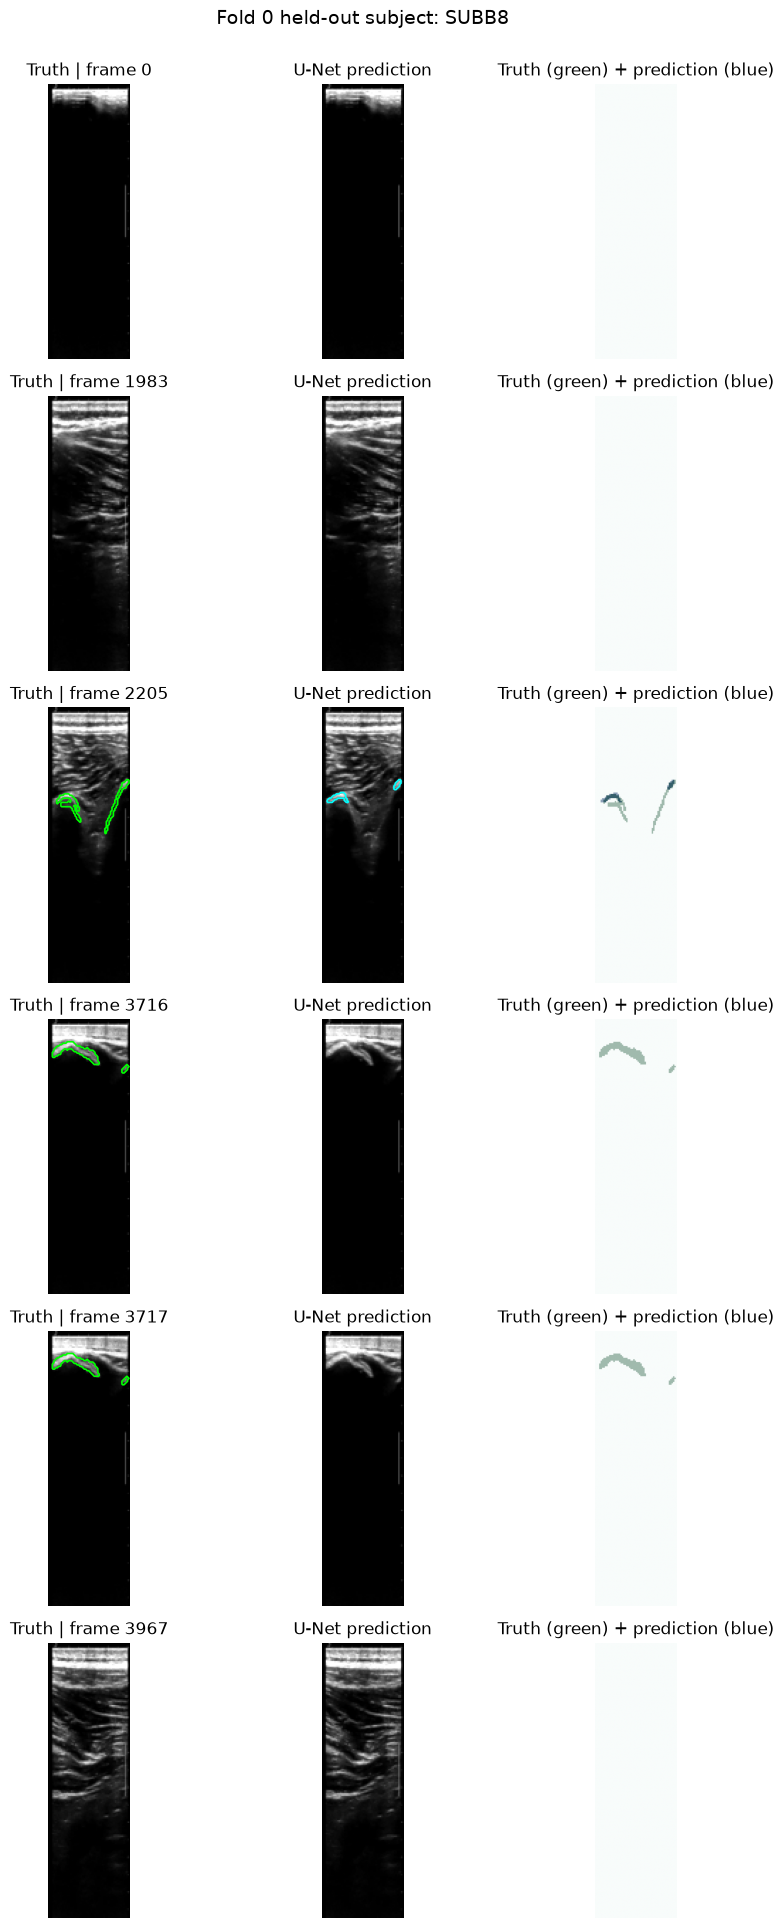

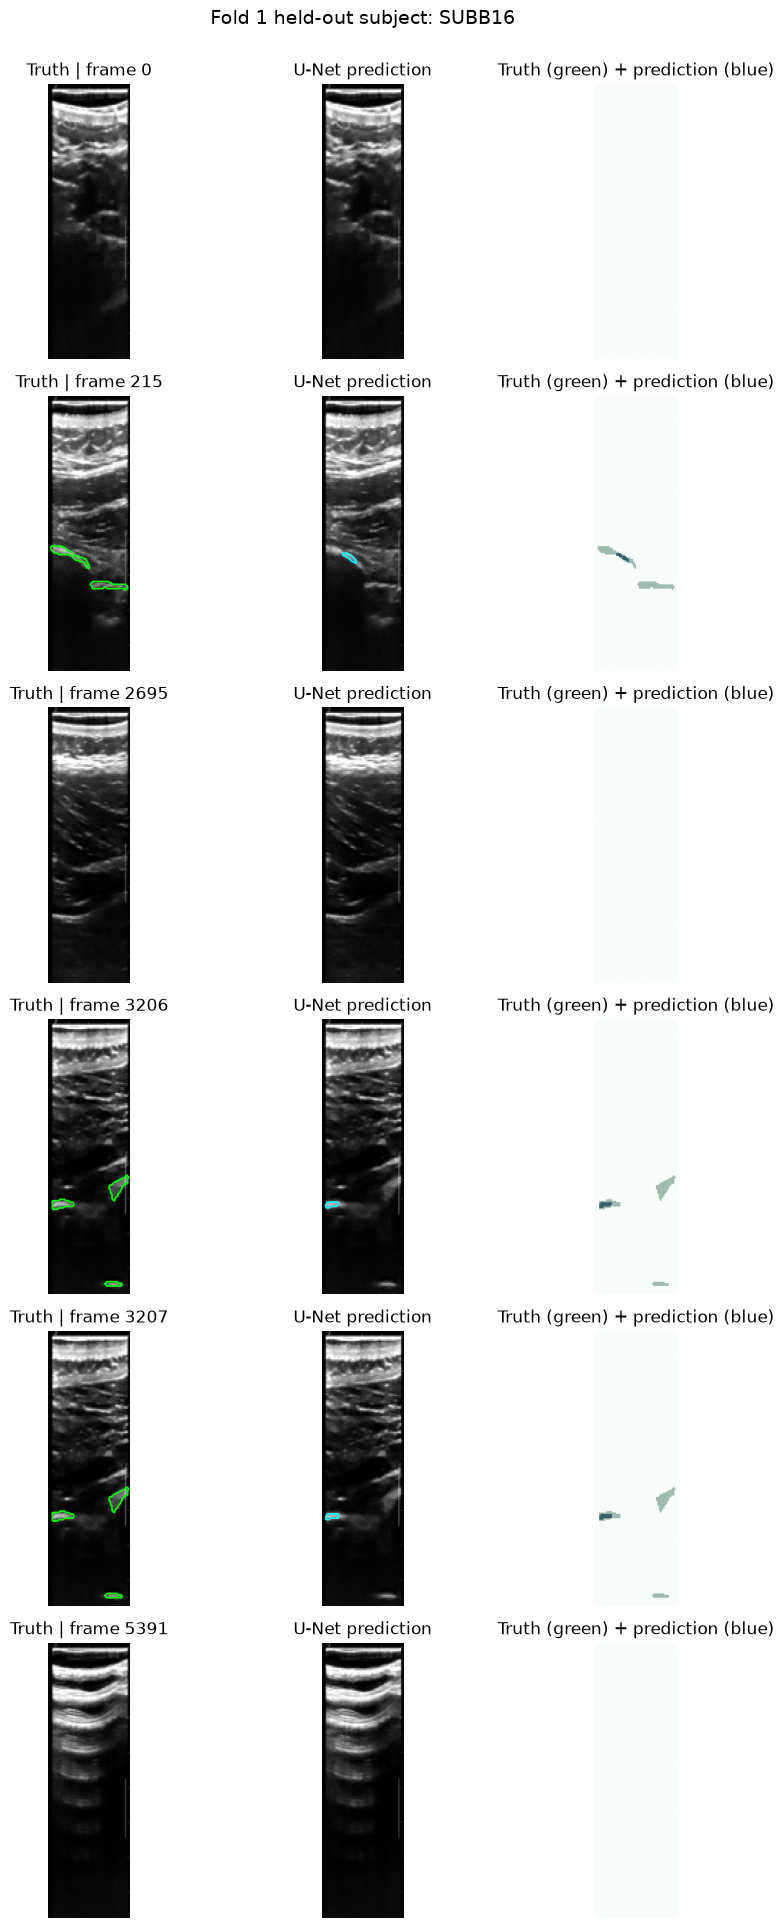

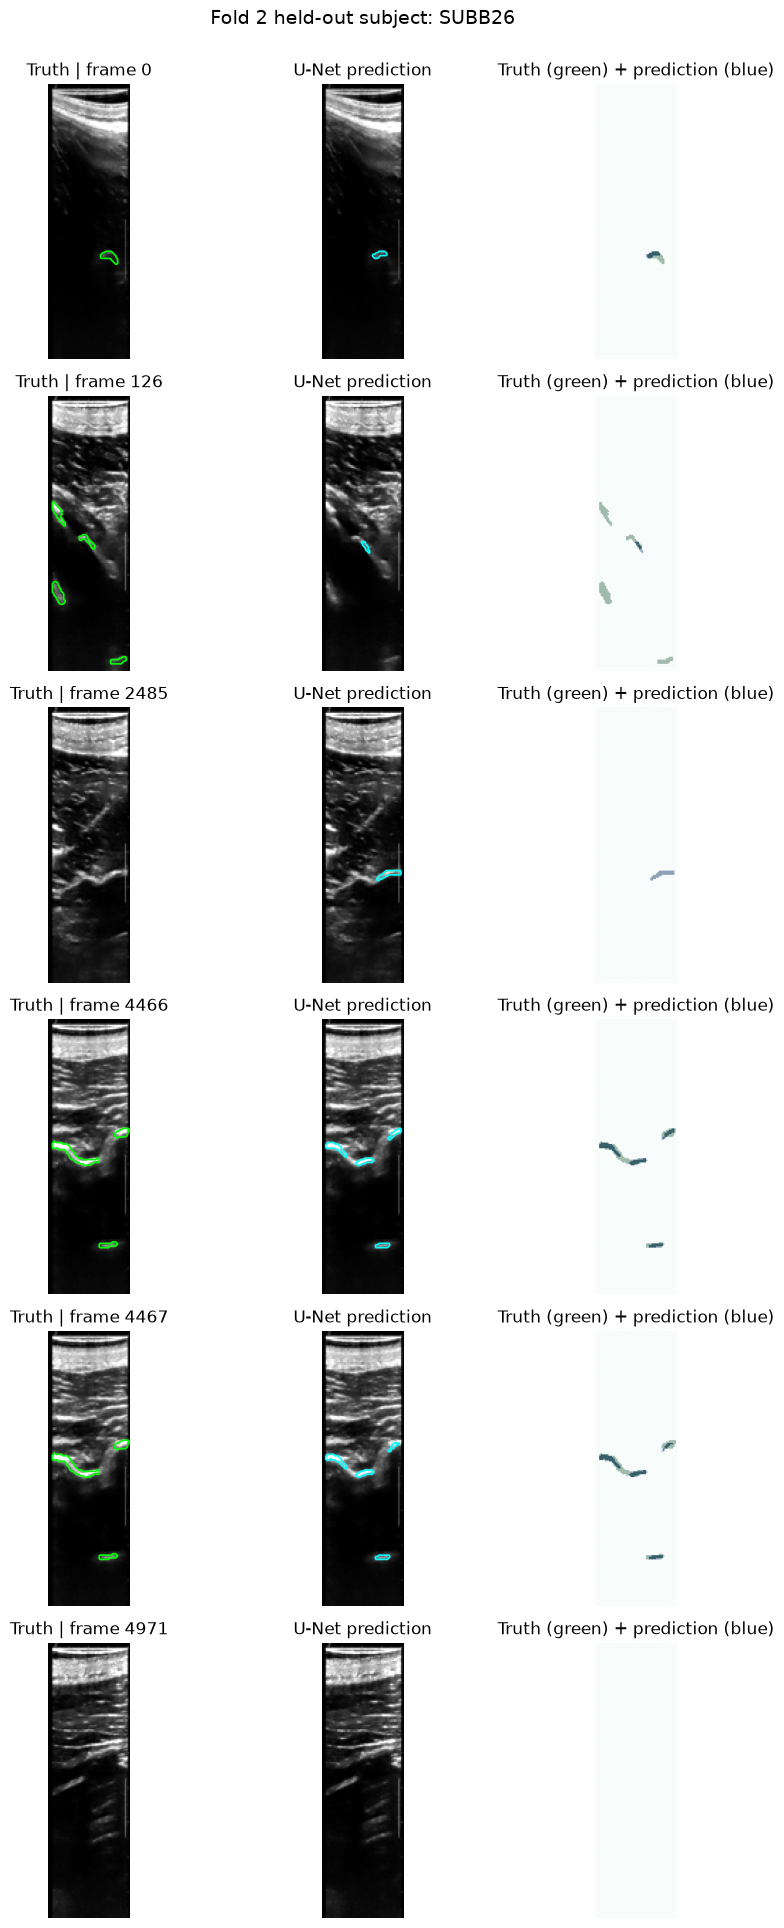

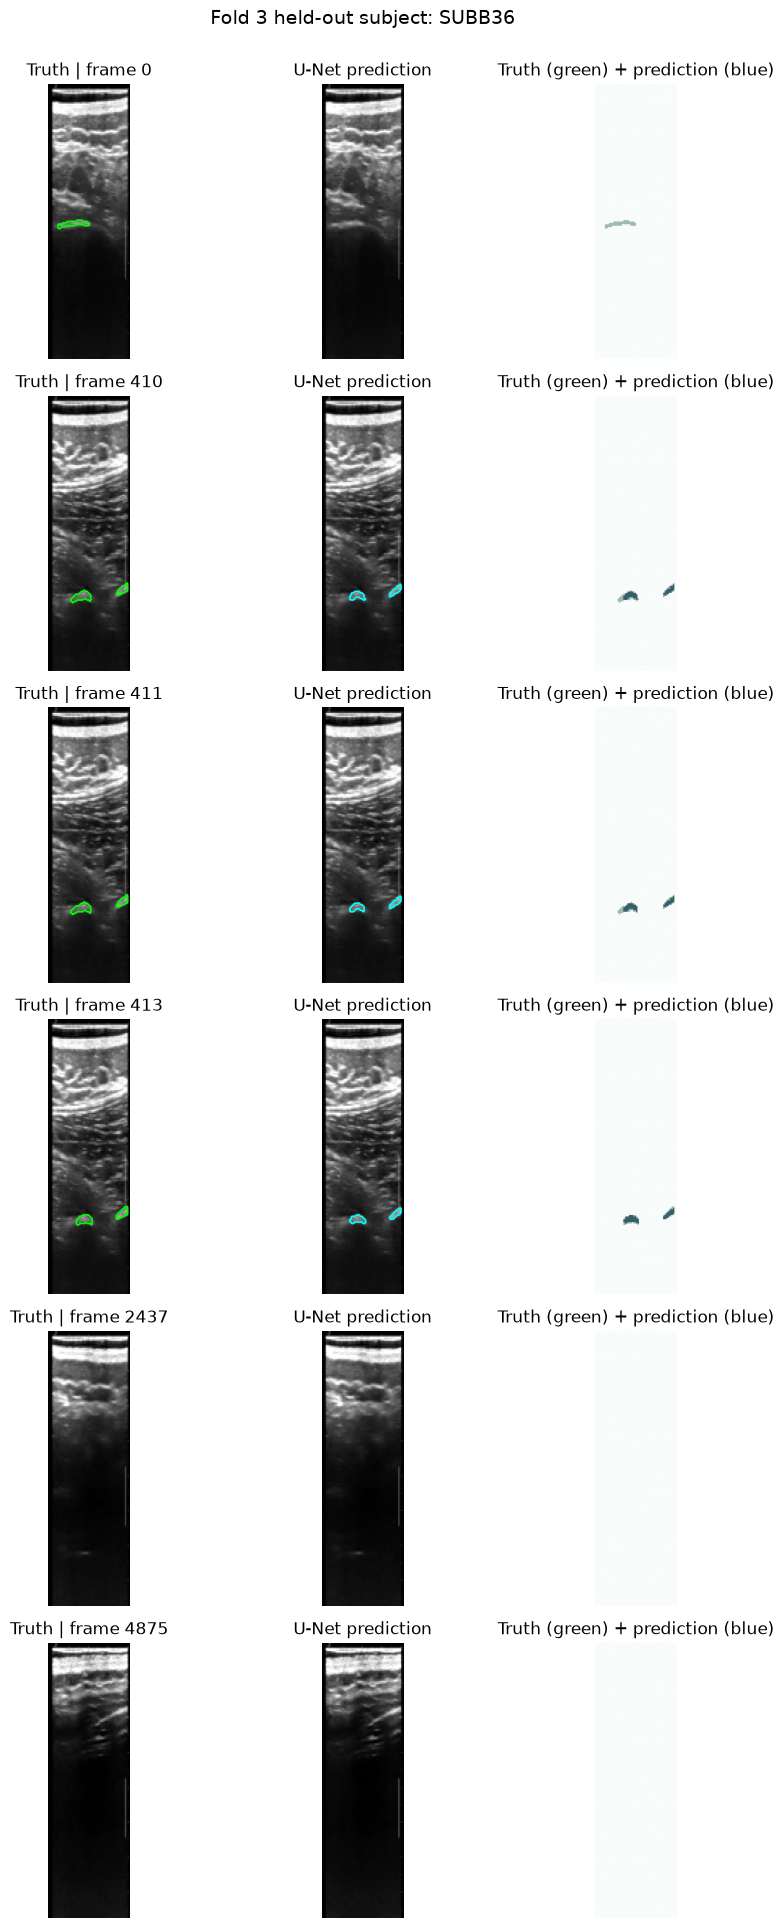

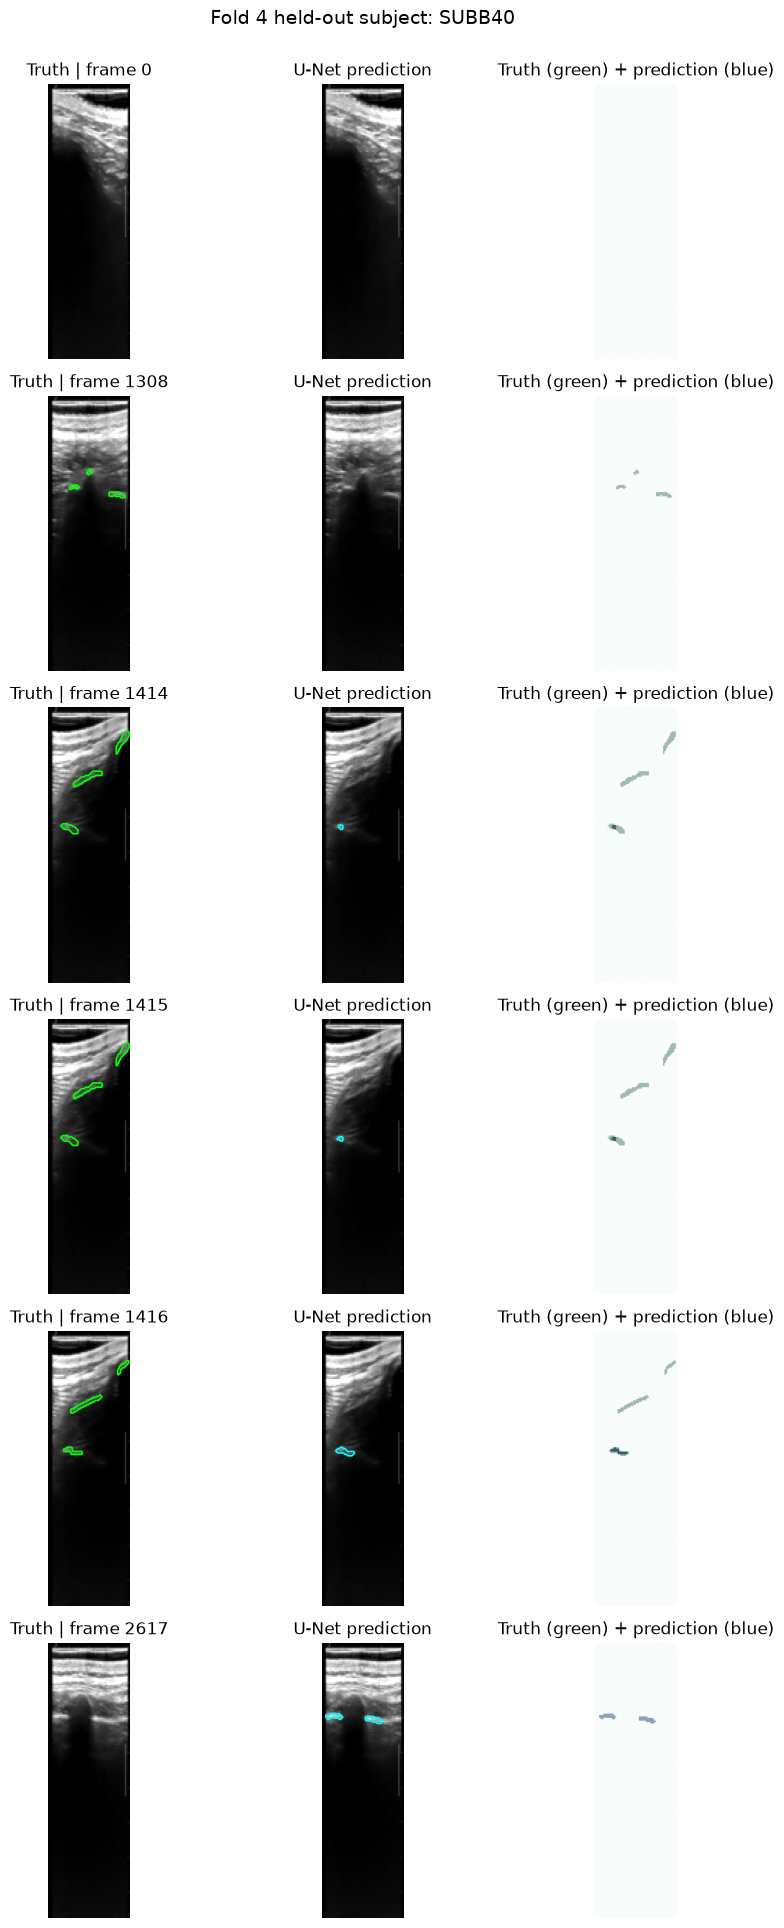

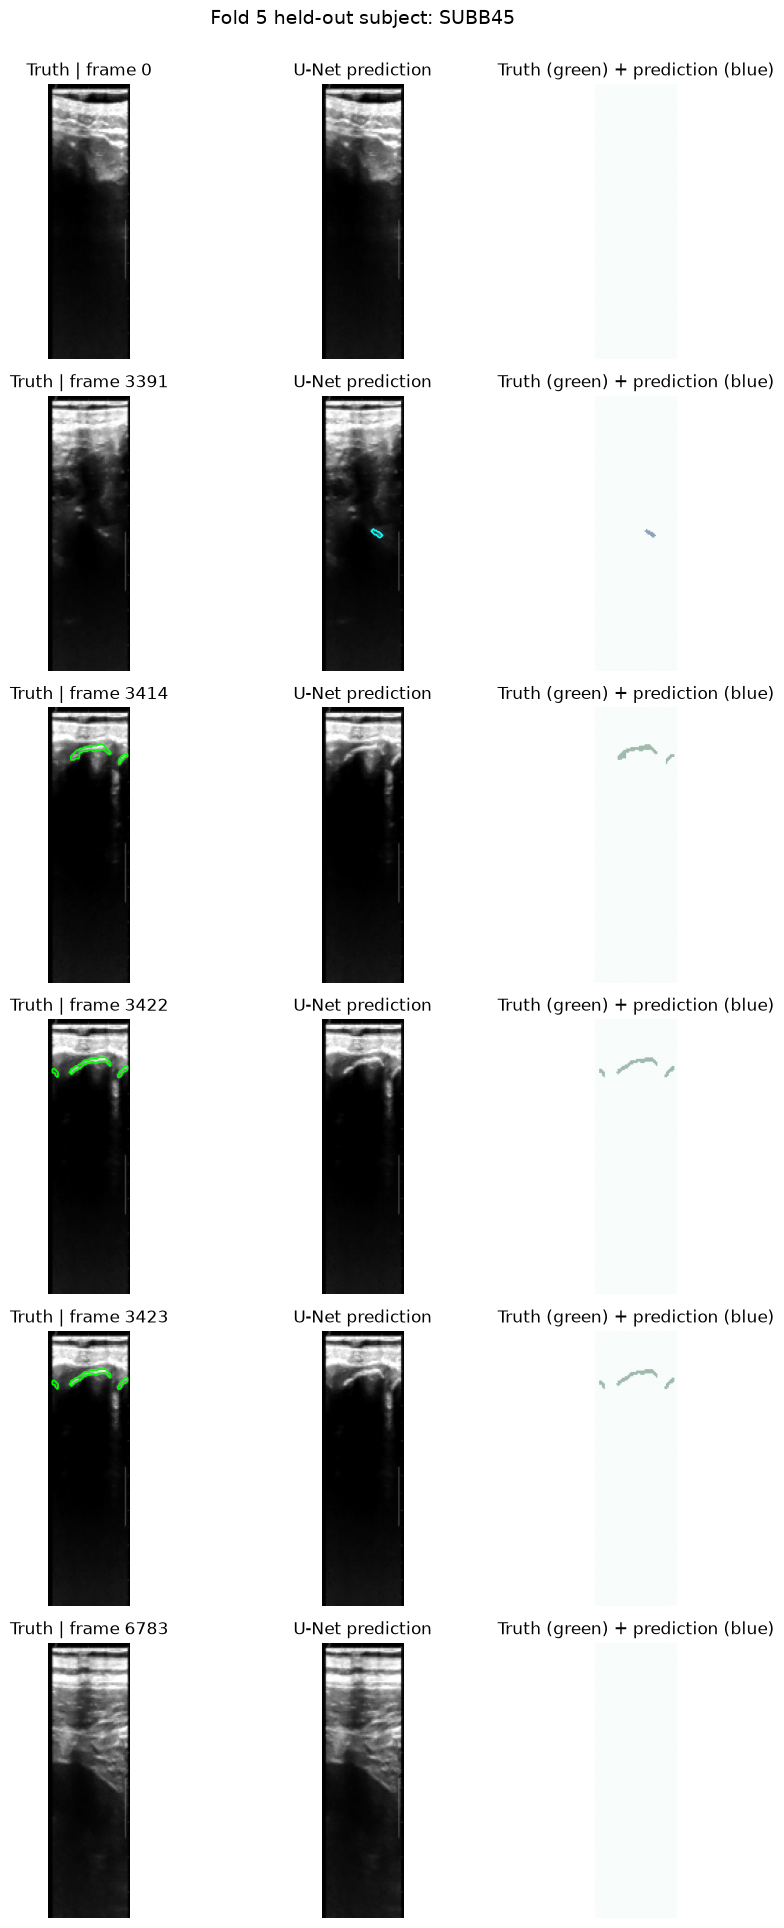

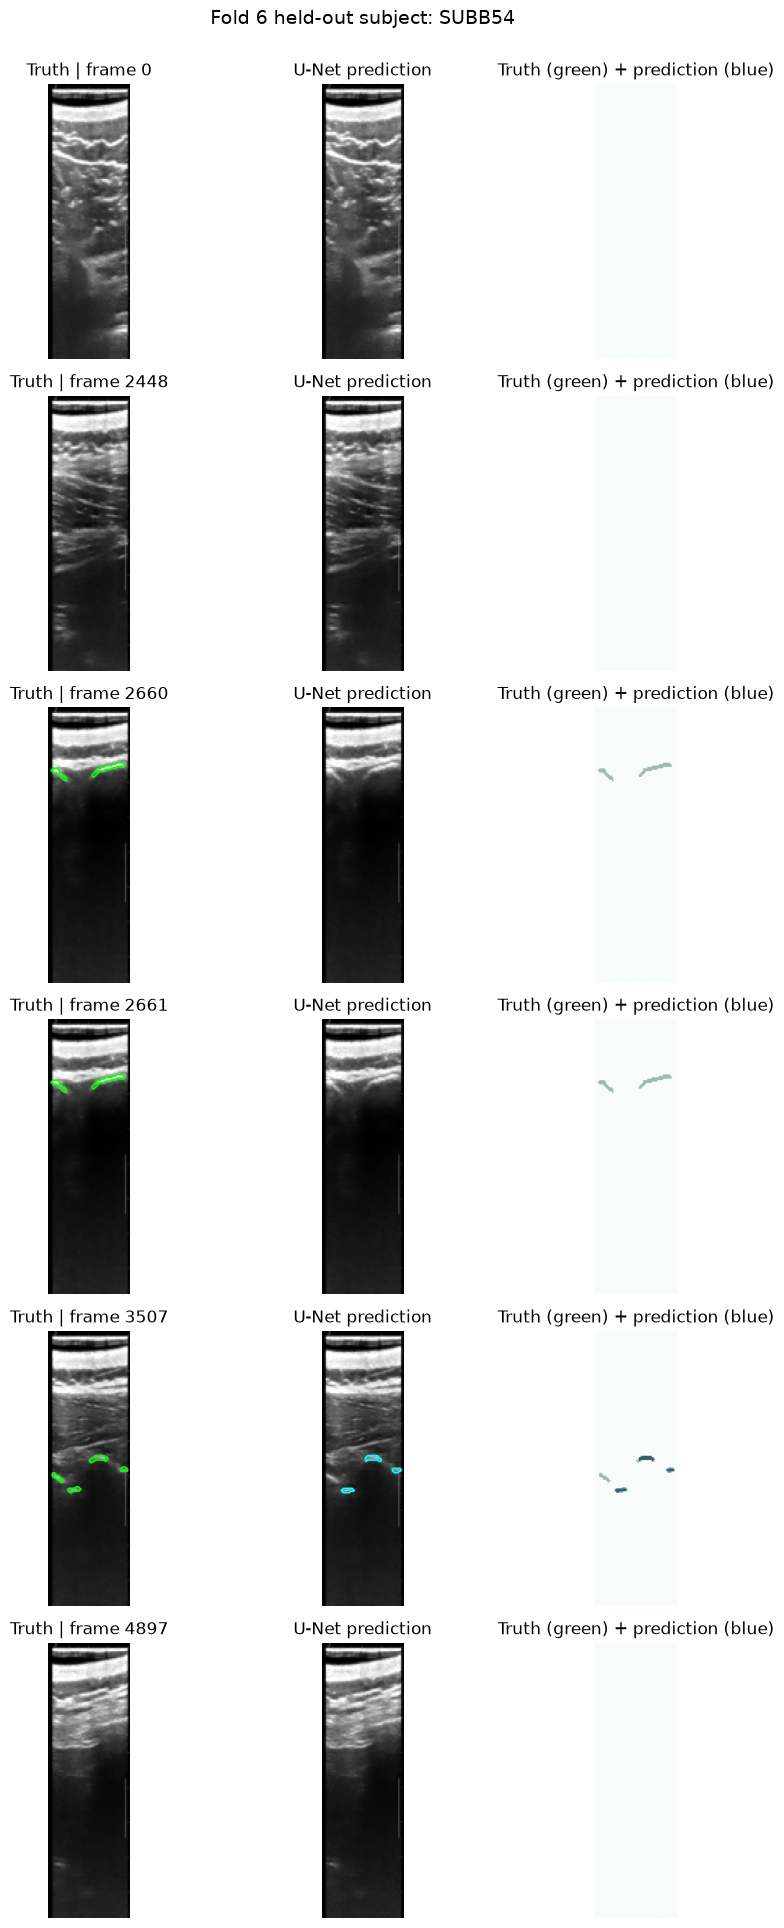

In [19]:
metric_columns = [
    "subject_micro_dice",
    "subject_micro_iou",
    "subject_micro_precision",
    "subject_micro_recall",
    "mean_frame_dice_gt_nonempty",
    "mean_hd95_both_nonempty_pixels",
]
aggregate_rows = []
for metric in metric_columns:
    values = pd.to_numeric(summary_df[metric], errors="coerce")
    aggregate_rows.append({
        "metric": metric,
        "mean_across_subjects": float(values.mean()),
        "std_across_subjects": float(values.std(ddof=1)),
        "median_across_subjects": float(values.median()),
        "subjects_with_value": int(values.notna().sum()),
    })
aggregate_df = pd.DataFrame(aggregate_rows).set_index("metric")
aggregate_df.to_csv(RESULT_ROOT / "loso_aggregate_metrics.csv")
display(aggregate_df)


def choose_prediction_frames(subject, n=6):
    masks = PROCESSED[subject]["masks"]
    counts = np.zeros(len(masks), dtype=np.int64)
    for start in range(0, len(masks), 256):
        end = min(start + 256, len(masks))
        counts[start:end] = np.asarray(masks[start:end]).sum(axis=(1, 2))
    spread = np.linspace(0, len(masks) - 1, max(2, n // 2), dtype=int)
    nonempty = np.flatnonzero(counts > 0)
    top = nonempty[np.argsort(counts[nonempty])[-max(2, n - len(spread)):]] if len(nonempty) else []
    selected = np.unique(np.concatenate([spread, np.asarray(top, dtype=int)]))
    return selected[:n]


for fold in FOLDS:
    subject = fold["test_subject"]
    fold_dir = RESULT_ROOT / f"fold_{fold['fold']}_{subject}"
    predictions = np.load(fold_dir / f"{subject}_predictions.npy", mmap_mode="r")
    selected = choose_prediction_frames(subject, n=6)
    fig, axes = plt.subplots(len(selected), 3, figsize=(10, 3.2 * len(selected)), squeeze=False)
    for row, frame_index in enumerate(selected):
        image = np.asarray(PROCESSED[subject]["images"][frame_index])
        truth = np.asarray(PROCESSED[subject]["masks"][frame_index] > 0)
        prediction = np.asarray(predictions[frame_index] > 0)
        lo, hi = np.percentile(image, [1, 99])
        if hi <= lo:
            hi = lo + 1e-6
        axes[row, 0].imshow(image, cmap="gray", vmin=lo, vmax=hi)
        if truth.any():
            axes[row, 0].contour(truth.astype(float), levels=[0.5], colors="lime", linewidths=1.2)
        axes[row, 0].set_title(f"Truth | frame {frame_index}")
        axes[row, 1].imshow(image, cmap="gray", vmin=lo, vmax=hi)
        if prediction.any():
            axes[row, 1].contour(prediction.astype(float), levels=[0.5], colors="cyan", linewidths=1.2)
        axes[row, 1].set_title("U-Net prediction")
        axes[row, 2].imshow(truth, cmap="Greens", alpha=0.65, vmin=0, vmax=1)
        axes[row, 2].imshow(prediction, cmap="Blues", alpha=0.45, vmin=0, vmax=1)
        axes[row, 2].set_title("Truth (green) + prediction (blue)")
        for axis in axes[row]:
            axis.axis("off")
    fig.suptitle(f"Fold {fold['fold']} held-out subject: {subject}", y=1.002, fontsize=14)
    plt.tight_layout()
    figure_path = fold_dir / f"{subject}_qualitative_examples.png"
    plt.savefig(figure_path, dpi=160, bbox_inches="tight")
    plt.show()


## 9. Final output audit


In [20]:
required_subjects = set(SUBJECTS)
observed_subjects = set(summary_df["subject"])
if observed_subjects != required_subjects:
    raise RuntimeError(f"Missing held-out results: {required_subjects - observed_subjects}")
if summary_df["fold"].nunique() != 7:
    raise RuntimeError("Expected exactly seven unique LOSO folds")
if not np.isfinite(summary_df["subject_micro_dice"]).all():
    raise RuntimeError("At least one fold has a non-finite subject Dice")

audit = {
    "status": "PASS",
    "run_signature": RUN_SIGNATURE,
    "folds": 7,
    "held_out_subjects": summary_df.sort_values("fold")["subject"].tolist(),
    "mean_subject_micro_dice": float(summary_df["subject_micro_dice"].mean()),
    "total_training_minutes": float(summary_df["training_minutes"].sum()),
    "total_evaluation_minutes": float(summary_df["evaluation_minutes"].sum()),
}
(RESULT_ROOT / "final_audit.json").write_text(json.dumps(audit, indent=2), encoding="utf-8")
print(json.dumps(audit, indent=2))
print("\nResults directory:", RESULT_ROOT)
print("Save a Kaggle notebook version with outputs to preserve this directory.")


{
  "status": "PASS",
  "run_signature": "a757886b957175e4",
  "folds": 7,
  "held_out_subjects": [
    "SUBB8",
    "SUBB16",
    "SUBB26",
    "SUBB36",
    "SUBB40",
    "SUBB45",
    "SUBB54"
  ],
  "mean_subject_micro_dice": 0.26141136009116456,
  "total_training_minutes": 8.292387793316657,
  "total_evaluation_minutes": 0.8400196999666719
}

Results directory: /kaggle/working/subb_unet_tpu/results
Save a Kaggle notebook version with outputs to preserve this directory.


## How to interpret the result

The main baseline number is the mean and standard deviation of `subject_micro_dice` across the seven held-out subjects. Do not average all frames from all subjects as if they were independent folds. Retain the per-subject table because a large mean can hide one subject on which the model fails.

The training-time Dice printed during epochs is computed from soft probabilities on the deliberately balanced training stream. It is **not** the cross-validation result. The actual LOSO results appear only after inference on the held-out subject and are written to `loso_subject_summary.csv`.
